<a href="https://colab.research.google.com/github/JonasFanZ/114-2-Programing-Language/blob/main/HW4_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [206]:
# ============================================================
# 0. 安裝需要的套件
# ============================================================
# yfinance：抓股票資料
# mplfinance：畫K線圖
# pypdf：讀PDF文字
# google-genai：呼叫 Gemini 與 Embedding
# faiss-cpu：建立向量資料庫，做語意相似度搜尋
# gradio：建立簡單前端

!pip install yfinance mplfinance pypdf google-genai faiss-cpu gradio -q

In [207]:
# ============================================================
# 1. 匯入套件
# ============================================================

import os
import json
import time

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf

from pypdf import PdfReader

# FAISS：向量相似度搜尋
import faiss

# Gemini API
from google import genai
from google.colab import userdata

# Gradio 前端
import gradio as gr

In [208]:
# ============================================================
# 2. 使用者設定區
# ============================================================
# 台股格式：
# 上市股票：股票代號.TW，例如 3711.TW、2330.TW、2317.TW
# 上櫃股票：股票代號.TWO，例如 6488.TWO
#
# period 可以改：
# "3mo" = 近三個月
# "6mo" = 近半年
# "1y"  = 近一年

TICKER = "3711.TW"
PERIOD = "6mo"
INTERVAL = "1d"

# 你的資金與單筆風險設定
CAPITAL = 100000          # 總資金，例如10萬
RISK_PER_TRADE = 0.01     # 單筆最大風險，例如1%

# 是否要畫K線圖
SHOW_CHART = True

In [209]:
# ============================================================
# 3. 抓取股票 OHLCV 資料：支援上市 .TW 與上櫃 .TWO
# ============================================================

def normalize_ticker_candidates(ticker):
    """
    根據使用者輸入，產生可能的 yfinance 股票代號。

    使用者輸入 2330：
    會嘗試 2330.TW、2330.TWO

    使用者輸入 6488：
    會嘗試 6488.TW、6488.TWO

    使用者輸入 2330.TW：
    會直接使用 2330.TW
    """
    ticker = str(ticker).strip().upper()

    # 如果使用者已經輸入 .TW 或 .TWO，就直接使用
    if ticker.endswith(".TW") or ticker.endswith(".TWO"):
        return [ticker]

    # 如果只輸入純數字，就自動嘗試上市與上櫃
    if ticker.isdigit():
        return [f"{ticker}.TW", f"{ticker}.TWO"]

    # 其他情況就先原樣嘗試
    return [ticker]


def fetch_stock_data(ticker, period="6mo", interval="1d"):
    """
    從 yfinance 抓股票資料。
    支援自動嘗試 .TW 與 .TWO。

    回傳：
    df：股票資料
    used_ticker：實際成功抓到資料的股票代號
    """
    candidates = normalize_ticker_candidates(ticker)

    last_error = None

    for candidate in candidates:
        try:
            df = yf.download(
                candidate,
                period=period,
                interval=interval,
                auto_adjust=False,
                progress=False
            )

            if df is None or df.empty:
                continue

            # yfinance 有時候會回傳 MultiIndex 欄位，這邊壓平成一般欄位
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

            required_cols = ["Open", "High", "Low", "Close", "Volume"]

            # 檢查欄位是否完整
            if not all(col in df.columns for col in required_cols):
                continue

            df = df[required_cols].copy()
            df = df.dropna()

            if len(df) == 0:
                continue

            print(f"成功抓到資料：{candidate}")
            return df, candidate

        except Exception as e:
            last_error = e
            continue

    raise ValueError(
        f"抓不到 {ticker} 的資料。已嘗試：{candidates}。"
        f"請確認股票代號是否正確，例如上市 2330.TW，上櫃 6488.TWO。"
    )

In [210]:
# ============================================================
# 4. 計算技術分析特徵：補強防呆版
# ============================================================
# 這一段是專題最重要的部分：
# Python 先負責算出客觀特徵，Gemini 只負責根據 PDF 規則解釋。
#
# 這版修正：
# 1. 確保 PrevHigh60 / PrevHigh120 一定會建立
# 2. 即使資料不到 120 筆，也不會讓整個分析壞掉
# 3. 保留舊欄位 Breakout / ValidBreakout，避免後面區塊壞掉

def add_technical_features(df):
    """
    在原本的 OHLCV 資料上，增加技術分析欄位。
    """

    df = df.copy()

    # ---------- 基本欄位檢查 ----------
    required_base_cols = ["Open", "High", "Low", "Close", "Volume"]
    missing_base_cols = [col for col in required_base_cols if col not in df.columns]

    if missing_base_cols:
        raise ValueError(f"OHLCV 資料缺少必要欄位：{missing_base_cols}")

    # ---------- 均線 ----------
    df["MA5"] = df["Close"].rolling(5, min_periods=5).mean()
    df["MA10"] = df["Close"].rolling(10, min_periods=10).mean()
    df["MA20"] = df["Close"].rolling(20, min_periods=20).mean()

    # ---------- 成交量均量 ----------
    df["VolMA20"] = df["Volume"].rolling(20, min_periods=20).mean()
    df["VolumeRatio"] = df["Volume"] / df["VolMA20"]

    # ---------- 近期前高前低 ----------
    # 判斷今天有沒有突破，不能把今天的 high 算進去。
    # 所以要 shift(1)，只看昨天以前的高低點。
    df["PrevHigh20"] = df["High"].shift(1).rolling(20, min_periods=20).max()
    df["PrevLow20"] = df["Low"].shift(1).rolling(20, min_periods=20).min()

    # 60日與120日資料可能因為 period 太短而不足。
    # 這裡使用 min_periods=20，代表至少有20筆資料就先給一個參考值。
    # 這樣不會因為 3mo 資料不足而整個分析壞掉。
    df["PrevHigh60"] = df["High"].shift(1).rolling(60, min_periods=20).max()
    df["PrevLow60"] = df["Low"].shift(1).rolling(60, min_periods=20).min()

    df["PrevHigh120"] = df["High"].shift(1).rolling(120, min_periods=20).max()
    df["PrevLow120"] = df["Low"].shift(1).rolling(120, min_periods=20).min()

    # ---------- 突破判斷 ----------
    # PDF 強調突破要用收盤確認，不用盤中尖刺確認。
    df["Breakout20"] = df["Close"] > df["PrevHigh20"]

    # 放量突破：收盤突破 + 成交量大於20日均量1.5倍
    df["ValidBreakout20"] = (df["Breakout20"]) & (df["VolumeRatio"] >= 1.5)

    # 保留舊欄位名稱，避免後面區塊壞掉
    df["Breakout"] = df["Breakout20"]
    df["ValidBreakout"] = df["ValidBreakout20"]

    # ---------- K 線結構 ----------
    df["Body"] = (df["Close"] - df["Open"]).abs()
    df["Range"] = df["High"] - df["Low"]

    # 避免除以 0
    df["Range"] = df["Range"].replace(0, np.nan)

    df["UpperShadow"] = df["High"] - df[["Open", "Close"]].max(axis=1)
    df["LowerShadow"] = df[["Open", "Close"]].min(axis=1) - df["Low"]

    df["BodyRatio"] = df["Body"] / df["Range"]
    df["UpperShadowRatio"] = df["UpperShadow"] / df["Range"]
    df["LowerShadowRatio"] = df["LowerShadow"] / df["Range"]

    # ---------- K 線型態簡易判斷 ----------
    conditions = [
        (df["Close"] > df["Open"]) & (df["BodyRatio"] >= 0.6),
        (df["Close"] < df["Open"]) & (df["BodyRatio"] >= 0.6),
        (df["UpperShadowRatio"] >= 0.5),
        (df["LowerShadowRatio"] >= 0.5),
    ]

    choices = [
        "長紅K，多方力道較強",
        "長黑K，空方力道較強",
        "長上影線，上方賣壓較明顯",
        "長下影線，下方承接較明顯",
    ]

    df["CandleType"] = np.select(conditions, choices, default="一般K線")

    return df

In [211]:
# ============================================================
# 5. 產生單一股票的技術分析摘要：補強防呆版
# ============================================================
# 這版修正：
# 1. 避免 KeyError: 'PrevHigh60'
# 2. 不再直接 df.dropna() 把 60日 / 120日資料不足的列全部刪掉
# 3. 如果缺技術欄位，會自動重新計算
# 4. 可以支援 3mo / 6mo / 1y
# 5. 保留後面第 11、12、15 區塊需要的 JSON 結構

def ensure_technical_columns(df):
    """
    確保 df 裡面有第5區塊需要用到的技術欄位。
    如果缺少欄位，就重新呼叫 add_technical_features(df) 補上。
    """

    required_columns = [
        "MA5", "MA10", "MA20",
        "VolMA20", "VolumeRatio",
        "PrevHigh20", "PrevLow20",
        "PrevHigh60", "PrevLow60",
        "PrevHigh120", "PrevLow120",
        "Breakout20", "ValidBreakout20",
        "Breakout", "ValidBreakout",
        "Body", "Range",
        "UpperShadow", "LowerShadow",
        "BodyRatio", "UpperShadowRatio", "LowerShadowRatio",
        "CandleType"
    ]

    missing_columns = [col for col in required_columns if col not in df.columns]

    if missing_columns:
        print("偵測到缺少技術欄位，正在重新計算：")
        print(missing_columns)
        df = add_technical_features(df)

    return df


def safe_float(value, default=None):
    """
    安全轉成 float。
    如果 value 是 NaN，就回傳 default。
    """
    try:
        if pd.isna(value):
            return default
        return float(value)
    except Exception:
        return default


def analyze_market_context(period="6mo"):
    """
    分析大盤市況。
    目前使用：
    1. ^TWII：台灣加權指數
    2. 0050.TW：台灣50 ETF

    如果抓不到資料，不讓程式中斷，而是回傳 unavailable。
    """

    market_result = {
        "available": False,
        "summary": "無法取得大盤資料",
        "twii": None,
        "etf_0050": None
    }

    def analyze_one_market_symbol(symbol):
        try:
            market_df, used_symbol = fetch_stock_data(symbol, period=period, interval="1d")
            market_df = ensure_technical_columns(market_df)

            # 只刪掉判斷大盤必須用到的欄位為空的列
            market_df = market_df.dropna(subset=["MA20", "MA10", "MA5"]).copy()

            if len(market_df) < 20:
                return None

            latest = market_df.iloc[-1]

            close = float(latest["Close"])
            ma5 = float(latest["MA5"])
            ma10 = float(latest["MA10"])
            ma20 = float(latest["MA20"])

            if close > ma5 > ma10 > ma20:
                status = "偏多：價格站上 MA5、MA10、MA20，且均線多頭排列"
                bullish = True
            elif close > ma20:
                status = "中性偏多：價格在 MA20 上方，但均線排列尚未完整"
                bullish = True
            elif close < ma20:
                status = "偏弱：價格在 MA20 下方"
                bullish = False
            else:
                status = "中性：價格接近 MA20"
                bullish = False

            return {
                "symbol": used_symbol,
                "close": round(close, 2),
                "MA5": round(ma5, 2),
                "MA10": round(ma10, 2),
                "MA20": round(ma20, 2),
                "status": status,
                "bullish": bullish
            }

        except Exception as e:
            return {
                "symbol": symbol,
                "error": str(e),
                "bullish": False
            }

    twii = analyze_one_market_symbol("^TWII")
    etf_0050 = analyze_one_market_symbol("0050.TW")

    market_result["twii"] = twii
    market_result["etf_0050"] = etf_0050
    market_result["available"] = twii is not None or etf_0050 is not None

    bullish_count = 0
    total_count = 0

    for item in [twii, etf_0050]:
        if item is not None and "bullish" in item:
            total_count += 1
            if item["bullish"]:
                bullish_count += 1

    if total_count == 0:
        market_result["summary"] = "無法判斷大盤市況"
    elif bullish_count == total_count:
        market_result["summary"] = "大盤環境偏多，較有利於順勢交易"
    elif bullish_count == 0:
        market_result["summary"] = "大盤環境偏弱，應降低追價與進場意願"
    else:
        market_result["summary"] = "大盤環境中性，需更嚴格檢查個股條件"

    return market_result


def analyze_latest_signal(df, ticker, capital=100000, risk_per_trade=0.01, market_context=None):
    """
    根據最新一根K線，整理出交易分析需要的特徵。

    參數：
    df：股票資料
    ticker：實際分析的股票代號，例如 2330.TW、6488.TWO
    capital：總資金
    risk_per_trade：單筆最大風險比例，例如 0.01 = 1%
    market_context：大盤市況分析結果
    """

    # 確保技術欄位存在
    df = ensure_technical_columns(df)

    # 只針對必要欄位 dropna，不要整個 df.dropna()
    # 因為 PrevHigh120 在 3mo / 6mo 時可能資料不足，但不應該害整個分析失敗。
    required_for_latest = [
        "MA5", "MA10", "MA20",
        "VolMA20", "VolumeRatio",
        "PrevHigh20", "PrevLow20",
        "Breakout20", "ValidBreakout20",
        "UpperShadowRatio", "LowerShadowRatio",
        "CandleType"
    ]

    df = df.dropna(subset=required_for_latest).copy()

    if len(df) < 30:
        raise ValueError("資料太少，至少需要30筆以上可用日K資料。建議把資料期間改成 6mo 或 1y。")

    latest = df.iloc[-1]
    latest_date = df.index[-1].strftime("%Y-%m-%d")

    close = float(latest["Close"])
    open_ = float(latest["Open"])
    high = float(latest["High"])
    low = float(latest["Low"])
    volume = float(latest["Volume"])

    ma5 = float(latest["MA5"])
    ma10 = float(latest["MA10"])
    ma20 = float(latest["MA20"])
    vol_ma20 = float(latest["VolMA20"])
    volume_ratio = float(latest["VolumeRatio"])

    prev_high20 = float(latest["PrevHigh20"])
    prev_low20 = float(latest["PrevLow20"])

    prev_high60 = safe_float(latest.get("PrevHigh60"), None)
    prev_low60 = safe_float(latest.get("PrevLow60"), None)

    prev_high120 = safe_float(latest.get("PrevHigh120"), None)
    prev_low120 = safe_float(latest.get("PrevLow120"), None)

    # ============================================================
    # A. 均線多空排列判斷
    # ============================================================

    if close > ma5 > ma10 > ma20:
        ma_status = "多頭排列，價格站上MA5、MA10、MA20"
        ma_bullish = True
    elif close < ma5 < ma10 < ma20:
        ma_status = "空頭排列，價格跌破MA5、MA10、MA20"
        ma_bullish = False
    elif close > ma20:
        ma_status = "價格在MA20上方，偏多但排列未完全明確"
        ma_bullish = True
    else:
        ma_status = "價格在MA20下方，偏弱"
        ma_bullish = False

    # ============================================================
    # B. 趨勢粗略判斷
    # ============================================================

    recent_20 = df.tail(20)

    first_half = recent_20.iloc[:10]
    second_half = recent_20.iloc[10:]

    first_high = first_half["High"].max()
    second_high = second_half["High"].max()

    first_low = first_half["Low"].min()
    second_low = second_half["Low"].min()

    higher_high = second_high > first_high
    higher_low = second_low > first_low

    if higher_high and higher_low:
        trend = "上升趨勢：近期高點更高、低點提高"
        trend_type = "uptrend"
    elif (not higher_high) and (not higher_low):
        trend = "下降或轉弱：近期高點未創高、低點未提高"
        trend_type = "downtrend_or_weak"
    else:
        trend = "盤整或趨勢不明確"
        trend_type = "sideways_or_unclear"

    # ============================================================
    # C. 箱體判斷：斜率 + 區間寬度 + 觸碰次數版
    # ============================================================
    # 核心想法：
    # 箱型整理不只是「價格在某個區間」，
    # 還應該滿足「整體沒有明顯往上或往下傾斜」。
    #
    # 所以這版加入：
    # 1. trend_slope_pct_per_day：近20日收盤價的百分比斜率
    # 2. slope_is_flat：斜率是否接近水平
    # 3. box_width_pct：區間寬度
    # 4. resistance/support test count：支撐壓力測試次數
    #
    # 為什麼不用單純 dy/dx？
    # 因為 50 元股票漲 5 元，跟 500 元股票漲 5 元意義不同。
    # 所以這裡用 slope / mean_price 轉成百分比斜率。

    box_window = df.iloc[-21:-1].copy()

    if len(box_window) < 10:
        raw_box_high = prev_high20
        raw_box_low = prev_low20

        high_quantile_70 = prev_high20
        high_quantile_80 = prev_high20
        low_quantile_20 = prev_low20

        box_high = prev_high20
        box_low = prev_low20

        box_spike_high = False

        trend_slope = 0
        trend_slope_pct_per_day = 0
        slope_abs_pct_per_day = 0
        slope_is_flat = True
        slope_direction = "sideways"

    else:
        raw_box_high = float(box_window["High"].max())
        raw_box_low = float(box_window["Low"].min())

        # 主要壓力區：使用高點 70% 分位數，避免單一尖刺高點
        high_quantile_70 = float(box_window["High"].quantile(0.70))
        high_quantile_80 = float(box_window["High"].quantile(0.80))

        # 支撐參考
        low_quantile_20 = float(box_window["Low"].quantile(0.20))

        # 判斷是否有尖刺高點
        near_raw_high_count = int((box_window["High"] >= raw_box_high * 0.98).sum())

        box_spike_high = bool(
            raw_box_high > high_quantile_70 * 1.05
            and near_raw_high_count <= 2
        )

        if box_spike_high:
            box_high = high_quantile_70
        else:
            box_high = raw_box_high

        # 支撐先用 raw low，因為前低通常是明確結構
        box_low = raw_box_low

        # ------------------------------------------------------------
        # 近20日斜率計算
        # ------------------------------------------------------------
        # x = 0,1,2,...,n-1 代表交易日
        # y = close price
        # np.polyfit(x, y, 1)[0] 會得到線性回歸斜率
        # 再除以平均股價，轉成「每天平均變動百分比」
        closes = box_window["Close"].values
        x = np.arange(len(closes))

        trend_slope = float(np.polyfit(x, closes, 1)[0])
        mean_price = float(np.mean(closes))

        if mean_price > 0:
            trend_slope_pct_per_day = trend_slope / mean_price
        else:
            trend_slope_pct_per_day = 0

        slope_abs_pct_per_day = abs(trend_slope_pct_per_day)

        # 參數：
        # 0.005 = 每天 0.5%
        # 近20日來說，這已經不算完全水平，但作為初版可接受。
        slope_flat_threshold = 0.005

        slope_is_flat = slope_abs_pct_per_day <= slope_flat_threshold

        if trend_slope_pct_per_day > slope_flat_threshold:
            slope_direction = "uptrend"
        elif trend_slope_pct_per_day < -slope_flat_threshold:
            slope_direction = "downtrend"
        else:
            slope_direction = "sideways"

    # ------------------------------------------------------------
    # 箱體寬度
    # ------------------------------------------------------------
    box_width_pct = (box_high - box_low) / box_low if box_low > 0 else np.nan

    # ------------------------------------------------------------
    # 接近壓力 / 支撐的次數
    # ------------------------------------------------------------
    resistance_test_count = int((box_window["High"] >= box_high * 0.98).sum()) if len(box_window) > 0 else 0
    support_test_count = int((box_window["Low"] <= box_low * 1.02).sum()) if len(box_window) > 0 else 0

    # ------------------------------------------------------------
    # 最終箱體判斷
    # ------------------------------------------------------------
    # 條件：
    # 1. 斜率接近水平
    # 2. 箱體寬度不要過大
    # 3. 壓力至少測試 2 次
    # 4. 支撐至少測試 1 次
    #
    # box_width_pct <= 0.25：
    # 題材股波動會比較大，所以先放到 25%。
    # 你如果覺得太鬆，可以改 0.20。
    box_is_tight = box_width_pct <= 0.25
    box_has_tests = resistance_test_count >= 2 and support_test_count >= 1

    clear_box = bool(
        slope_is_flat
        and box_is_tight
        and box_has_tests
    )

    # 潛在箱體：
    # 有時候斜率稍微偏上，但仍然有整理區間。
    # 給畫圖使用，不一定當作正式 clear_box。
    potential_box = bool(
        box_is_tight
        and box_has_tests
        and slope_abs_pct_per_day <= 0.009
    )

    if clear_box and box_spike_high:
        box_status = "近20日斜率接近水平，且已排除尖刺高點，箱體相對明確"
    elif clear_box:
        box_status = "近20日斜率接近水平，壓力與支撐都有被測試，箱體相對明確"
    elif potential_box:
        box_status = "近20日有接近箱體的結構，但斜率或波動仍略大，視為潛在整理區"
    elif not slope_is_flat and slope_direction == "uptrend":
        box_status = "近20日斜率明顯向上，較不像箱型整理，偏上升趨勢"
    elif not slope_is_flat and slope_direction == "downtrend":
        box_status = "近20日斜率明顯向下，較不像箱型整理，偏下降趨勢"
    elif not box_is_tight:
        box_status = "近20日區間過寬，箱體不夠明確"
    else:
        box_status = "近20日支撐或壓力測試次數不足，箱體不夠明確"
    # ============================================================
    # D. 突破判斷
    # ============================================================

    breakout = bool(latest["Breakout20"])
    valid_breakout = bool(latest["ValidBreakout20"])

    if breakout and volume_ratio >= 1.5 and clear_box:
        breakout_status = "收盤價突破20日前高，成交量放大，且前方箱體相對明確"
    elif breakout and volume_ratio >= 1.5:
        breakout_status = "收盤價突破20日前高且成交量放大，但前方箱體不夠明確"
    elif breakout:
        breakout_status = "收盤價突破20日前高，但量能沒有明顯放大"
    else:
        breakout_status = "尚未突破20日前高"

    breakout_upper_shadow_ratio = float(latest["UpperShadowRatio"]) if breakout else None
    breakout_has_long_upper_shadow = bool(
        breakout
        and breakout_upper_shadow_ratio is not None
        and breakout_upper_shadow_ratio >= 0.45
    )

    # ============================================================
    # E. 最近突破與假突破判斷：補強突破 K 棒結構
    # ============================================================
    # 目前突破 K 棒定義：
    # 最近 15 根 K 線中，Close > PrevHigh20 的最後一根。
    #
    # 這版額外記錄：
    # 1. 突破 K 棒日期
    # 2. 突破價位
    # 3. OHLCV
    # 4. K 棒實體比例
    # 5. 上影線比例
    # 6. 下影線比例
    # 7. 是否長紅 K
    # 8. 是否長上影
    # 9. 是否放量
    # 10. 是否為結構較好的突破 K 棒

    recent_15 = df.tail(15).copy()
    breakout_rows = recent_15[recent_15["Breakout20"] == True]

    recent_breakout_exists = len(breakout_rows) > 0
    last_breakout_date = None
    last_breakout_level = None
    days_after_breakout = None
    failed_breakout_within_5_days = False

    breakout_candle = {
        "exists": False,
        "date": None,
        "breakout_level": None,
        "open": None,
        "high": None,
        "low": None,
        "close": None,
        "volume": None,
        "volume_ratio": None,
        "body_ratio": None,
        "upper_shadow_ratio": None,
        "lower_shadow_ratio": None,
        "candle_type": None,
        "is_bullish": None,
        "is_long_bullish": None,
        "has_long_upper_shadow": None,
        "has_volume_expansion": None,
        "is_good_structure_breakout": None
    }

    if recent_breakout_exists:
        last_breakout_idx = breakout_rows.index[-1]
        last_breakout_row = df.loc[last_breakout_idx]

        last_breakout_date = last_breakout_idx.strftime("%Y-%m-%d")
        last_breakout_level = float(last_breakout_row["PrevHigh20"])

        # 計算距離最近一次突破過了幾個交易日
        last_breakout_position = df.index.get_loc(last_breakout_idx)
        latest_position = len(df) - 1
        days_after_breakout = latest_position - last_breakout_position

        # 取出突破 K 棒本身的結構
        bo_open = float(last_breakout_row["Open"])
        bo_high = float(last_breakout_row["High"])
        bo_low = float(last_breakout_row["Low"])
        bo_close = float(last_breakout_row["Close"])
        bo_volume = float(last_breakout_row["Volume"])

        bo_volume_ratio = safe_float(last_breakout_row.get("VolumeRatio"), None)
        bo_body_ratio = safe_float(last_breakout_row.get("BodyRatio"), None)
        bo_upper_shadow_ratio = safe_float(last_breakout_row.get("UpperShadowRatio"), None)
        bo_lower_shadow_ratio = safe_float(last_breakout_row.get("LowerShadowRatio"), None)

        bo_is_bullish = bo_close > bo_open
        bo_is_long_bullish = bool(
            bo_is_bullish
            and bo_body_ratio is not None
            and bo_body_ratio >= 0.55
        )

        bo_has_long_upper_shadow = bool(
            bo_upper_shadow_ratio is not None
            and bo_upper_shadow_ratio >= 0.45
        )

        bo_has_volume_expansion = bool(
            bo_volume_ratio is not None
            and bo_volume_ratio >= 1.5
        )

        # 結構較好的突破：
        # 1. 收盤突破
        # 2. 放量
        # 3. 紅 K
        # 4. 不是長上影
        # 5. 前方箱體明確
        bo_is_good_structure_breakout = bool(
            bo_close > last_breakout_level
            and bo_has_volume_expansion
            and bo_is_bullish
            and not bo_has_long_upper_shadow
            and clear_box
        )

        breakout_candle = {
            "exists": True,
            "date": last_breakout_date,
            "breakout_level": round(last_breakout_level, 2),
            "open": round(bo_open, 2),
            "high": round(bo_high, 2),
            "low": round(bo_low, 2),
            "close": round(bo_close, 2),
            "volume": int(bo_volume),
            "volume_ratio": round(bo_volume_ratio, 2) if bo_volume_ratio is not None else None,
            "body_ratio": round(bo_body_ratio, 2) if bo_body_ratio is not None else None,
            "upper_shadow_ratio": round(bo_upper_shadow_ratio, 2) if bo_upper_shadow_ratio is not None else None,
            "lower_shadow_ratio": round(bo_lower_shadow_ratio, 2) if bo_lower_shadow_ratio is not None else None,
            "candle_type": str(last_breakout_row["CandleType"]),
            "is_bullish": bool(bo_is_bullish),
            "is_long_bullish": bool(bo_is_long_bullish),
            "has_long_upper_shadow": bool(bo_has_long_upper_shadow),
            "has_volume_expansion": bool(bo_has_volume_expansion),
            "is_good_structure_breakout": bool(bo_is_good_structure_breakout)
        }

        # 突破後5天內，如果收盤跌回突破價下方，視為假突破風險
        after_breakout = df.iloc[last_breakout_position + 1 : min(last_breakout_position + 6, len(df))]

        if len(after_breakout) > 0:
            failed_breakout_within_5_days = bool((after_breakout["Close"] < last_breakout_level).any())

    if failed_breakout_within_5_days:
        false_breakout_status = "最近突破後5日內曾跌回突破價下方，疑似假突破風險"
    elif breakout_candle["has_long_upper_shadow"]:
        false_breakout_status = "最近突破K棒出現較長上影線，需留意假突破或上方賣壓"
    elif breakout_candle["exists"] and not breakout_candle["has_volume_expansion"]:
        false_breakout_status = "最近突破K棒量能不足，突破有效性較弱"
    else:
        false_breakout_status = "目前沒有明顯假突破訊號"

    # ============================================================
    # F. 回踩判斷
    # ============================================================

    pullback_candidate = False
    pullback_support = last_breakout_level if last_breakout_level is not None else prev_high20

    near_pullback_support = False
    hold_pullback_support = False
    pullback_volume_healthy = False
    pullback_has_stop_signal = False

    if pullback_support is not None and pullback_support > 0:
        near_pullback_support = abs(close - pullback_support) / pullback_support <= 0.03
        hold_pullback_support = low >= pullback_support * 0.97 and close >= pullback_support
        pullback_volume_healthy = volume_ratio <= 1.2

        pullback_has_stop_signal = bool(
            latest["LowerShadowRatio"] >= 0.35 or close > open_
        )

        pullback_candidate = bool(
            recent_breakout_exists
            and days_after_breakout is not None
            and days_after_breakout >= 1
            and days_after_breakout <= 10
            and near_pullback_support
            and hold_pullback_support
            and pullback_has_stop_signal
        )

    if pullback_candidate and pullback_volume_healthy:
        pullback_status = "符合突破後回踩候選：接近突破支撐、未有效跌破，且量能相對健康"
    elif pullback_candidate:
        pullback_status = "接近突破後回踩條件，但量能沒有明顯縮小"
    elif recent_breakout_exists and near_pullback_support:
        pullback_status = "最近有突破且價格接近支撐，但止跌或支撐條件不足"
    elif recent_breakout_exists:
        pullback_status = "最近有突破，但目前尚未回踩到明確支撐位置"
    else:
        pullback_status = "近期沒有明確突破，暫不構成突破後回踩"

    # ============================================================
    # G. 停損位置建議
    # ============================================================

    if breakout:
        stop_loss = low
        stop_loss_reason = "使用突破K棒低點作為停損"
    elif pullback_candidate:
        stop_loss = pullback_support * 0.97
        stop_loss_reason = "使用突破支撐下方約3%作為停損"
    else:
        stop_loss = prev_low20
        stop_loss_reason = "未出現明確突破或回踩，暫以20日低點作為結構停損參考"

    risk_per_share = close - stop_loss
    risk_pct = risk_per_share / close if close > 0 else np.nan

    # ============================================================
    # H. 停利目標與風險報酬比
    # ============================================================

    next_resistance = None

    if prev_high60 is not None and prev_high60 > close:
        next_resistance = prev_high60
    elif prev_high120 is not None and prev_high120 > close:
        next_resistance = prev_high120

    target_price_1R = close + risk_per_share if risk_per_share > 0 else np.nan

    if next_resistance is not None and risk_per_share > 0:
        target_price = next_resistance
        risk_reward_ratio = (target_price - close) / risk_per_share
        target_reason = "使用60日或120日前高作為下一個壓力目標"
    elif risk_per_share > 0:
        target_price = target_price_1R
        risk_reward_ratio = 1.0
        target_reason = "找不到明確下一個壓力，暫用1R作為目標"
    else:
        target_price = np.nan
        risk_reward_ratio = np.nan
        target_reason = "停損位置不合理，無法計算目標價"

    # ============================================================
    # I. 倉位計算
    # ============================================================

    max_loss_money = capital * risk_per_trade

    if risk_per_share > 0:
        suggested_shares = int(max_loss_money // risk_per_share)
        suggested_position_value = suggested_shares * close
    else:
        suggested_shares = 0
        suggested_position_value = 0

    # ============================================================
    # J. 交易成本粗估
    # ============================================================

    fee_rate = 0.001425
    tax_rate = 0.003

    estimated_buy_fee = suggested_position_value * fee_rate
    estimated_sell_fee = suggested_position_value * fee_rate
    estimated_sell_tax = suggested_position_value * tax_rate

    estimated_round_trip_cost = estimated_buy_fee + estimated_sell_fee + estimated_sell_tax

    estimated_round_trip_cost_pct = (
        estimated_round_trip_cost / suggested_position_value * 100
        if suggested_position_value > 0 else 0
    )

    # ============================================================
    # K. 禁止交易理由
    # ============================================================

    no_trade_reasons = []

    liquidity_ok = volume >= 1_000_000

    if not liquidity_ok:
        no_trade_reasons.append("成交量低於1000張，流動性不足")

    if not ma_bullish:
        no_trade_reasons.append("價格或均線結構偏弱，未通過趨勢濾網")

    if not clear_box and breakout:
        no_trade_reasons.append("雖然突破，但前方箱體不夠明確")

    if not breakout and not pullback_candidate:
        no_trade_reasons.append("目前沒有明確突破，也沒有符合突破後回踩")

    if breakout_has_long_upper_shadow:
        no_trade_reasons.append("突破K棒上影線偏長，可能有上方賣壓")

    if failed_breakout_within_5_days:
        no_trade_reasons.append("近期突破後曾跌回突破價下方，疑似假突破")

    if risk_per_share <= 0:
        no_trade_reasons.append("停損位置不合理，無法計算有效風險")
    elif risk_pct > 0.08:
        no_trade_reasons.append("停損距離超過8%，風險過大")

    if risk_reward_ratio is not None and not pd.isna(risk_reward_ratio) and risk_reward_ratio < 1:
        no_trade_reasons.append("到下一個目標價的風險報酬比低於1")

    if estimated_round_trip_cost_pct > 1:
        no_trade_reasons.append("預估交易成本占比偏高，短線目標可能被成本吃掉")

    if market_context is not None:
        market_summary = market_context.get("summary", "")
        if "偏弱" in market_summary:
            no_trade_reasons.append("大盤環境偏弱，應降低進場意願")

    # ============================================================
    # L. 整理成 JSON
    # ============================================================

    result = {
        "stock": ticker,
        "date": latest_date,

        "price": {
            "open": round(open_, 2),
            "high": round(high, 2),
            "low": round(low, 2),
            "close": round(close, 2),
            "volume": int(volume)
        },

        "moving_average": {
            "MA5": round(ma5, 2),
            "MA10": round(ma10, 2),
            "MA20": round(ma20, 2),
            "status": ma_status,
            "ma_bullish": bool(ma_bullish)
        },

        "volume": {
            "today_volume": int(volume),
            "volume_ma20": int(vol_ma20),
            "volume_ratio": round(volume_ratio, 2),
            "liquidity_ok": bool(liquidity_ok)
        },

        "market_context": market_context,

        "box": {
            "box_high": round(box_high, 2),
            "box_low": round(box_low, 2),

            # 原始最高 / 最低
            "raw_box_high": round(raw_box_high, 2),
            "raw_box_low": round(raw_box_low, 2),

            # 分位數參考
            "high_quantile_70": round(high_quantile_70, 2),
            "high_quantile_80": round(high_quantile_80, 2),
            "low_quantile_20": round(low_quantile_20, 2),

            # 是否偵測到尖刺高點
            "box_spike_high": bool(box_spike_high),

            # 斜率資訊
            "trend_slope": round(trend_slope, 4),
            "trend_slope_pct_per_day": round(trend_slope_pct_per_day * 100, 3),
            "slope_abs_pct_per_day": round(slope_abs_pct_per_day * 100, 3),
            "slope_is_flat": bool(slope_is_flat),
            "slope_direction": slope_direction,

            # 箱體資訊
            "box_width_pct": round(box_width_pct * 100, 2),
            "resistance_test_count": resistance_test_count,
            "support_test_count": support_test_count,
            "clear_box": bool(clear_box),
            "potential_box": bool(potential_box),
            "box_status": box_status
        },
        "support_resistance": {
            "prev_high_20": round(prev_high20, 2),
            "prev_low_20": round(prev_low20, 2),
            "prev_high_60": round(prev_high60, 2) if prev_high60 is not None else None,
            "prev_low_60": round(prev_low60, 2) if prev_low60 is not None else None,
            "prev_high_120": round(prev_high120, 2) if prev_high120 is not None else None,
            "prev_low_120": round(prev_low120, 2) if prev_low120 is not None else None,
            "next_resistance": round(next_resistance, 2) if next_resistance is not None else None
        },

        "trend": {
            "higher_high": bool(higher_high),
            "higher_low": bool(higher_low),
            "trend_type": trend_type,
            "trend_summary": trend
        },

                "breakout_analysis": {
            "breakout": breakout,
            "valid_breakout": valid_breakout,
            "breakout_status": breakout_status,
            "breakout_upper_shadow_ratio": round(breakout_upper_shadow_ratio, 2) if breakout_upper_shadow_ratio is not None else None,
            "breakout_has_long_upper_shadow": breakout_has_long_upper_shadow,
            "breakout_candle": breakout_candle
        },

        "pullback_analysis": {
            "recent_breakout_exists": bool(recent_breakout_exists),
            "last_breakout_date": last_breakout_date,
            "last_breakout_level": round(last_breakout_level, 2) if last_breakout_level is not None else None,
            "days_after_breakout": days_after_breakout,
            "near_pullback_support": bool(near_pullback_support),
            "hold_pullback_support": bool(hold_pullback_support),
            "pullback_volume_healthy": bool(pullback_volume_healthy),
            "pullback_has_stop_signal": bool(pullback_has_stop_signal),
            "pullback_candidate": bool(pullback_candidate),
            "pullback_status": pullback_status
        },

        "false_breakout_analysis": {
            "failed_breakout_within_5_days": bool(failed_breakout_within_5_days),
            "false_breakout_status": false_breakout_status
        },

        "signal": {
            "breakout": breakout,
            "valid_breakout": valid_breakout,
            "breakout_status": breakout_status,
            "pullback_candidate": bool(pullback_candidate),
            "pullback_status": pullback_status,
            "candle_type": str(latest["CandleType"])
        },

        "risk_management": {
            "capital": capital,
            "risk_per_trade": risk_per_trade,
            "max_loss_money": round(max_loss_money, 2),
            "entry_price_reference": round(close, 2),
            "stop_loss": round(stop_loss, 2),
            "stop_loss_reason": stop_loss_reason,
            "risk_per_share": round(risk_per_share, 2),
            "risk_pct": round(risk_pct * 100, 2),
            "suggested_shares": suggested_shares,
            "suggested_position_value": round(suggested_position_value, 2),
            "target_price_1R": round(target_price_1R, 2) if not pd.isna(target_price_1R) else None,
            "target_price": round(target_price, 2) if not pd.isna(target_price) else None,
            "target_reason": target_reason,
            "risk_reward_ratio": round(risk_reward_ratio, 2) if not pd.isna(risk_reward_ratio) else None
        },

        "transaction_cost": {
            "fee_rate": fee_rate,
            "tax_rate": tax_rate,
            "estimated_buy_fee": round(estimated_buy_fee, 2),
            "estimated_sell_fee": round(estimated_sell_fee, 2),
            "estimated_sell_tax": round(estimated_sell_tax, 2),
            "estimated_round_trip_cost": round(estimated_round_trip_cost, 2),
            "estimated_round_trip_cost_pct": round(estimated_round_trip_cost_pct, 2)
        },

        "no_trade_reasons": no_trade_reasons
    }

    return result


# ============================================================
# 5-1. 單獨測試用
# ============================================================
# 如果你只想用 Gradio，不一定要跑這段。
# 如果你想先在 Colab 測試 analysis_result，可以跑。

try:
    analysis_ticker = used_ticker
except NameError:
    analysis_ticker = TICKER

try:
    market_context = analyze_market_context(PERIOD)
except Exception as e:
    market_context = {
        "available": False,
        "summary": f"大盤資料取得失敗：{str(e)}"
    }

df = ensure_technical_columns(df)

analysis_result = analyze_latest_signal(
    df=df,
    ticker=analysis_ticker,
    capital=CAPITAL,
    risk_per_trade=RISK_PER_TRADE,
    market_context=market_context
)

print(json.dumps(analysis_result, ensure_ascii=False, indent=2))

成功抓到資料：^TWII
偵測到缺少技術欄位，正在重新計算：
['MA5', 'MA10', 'MA20', 'VolMA20', 'VolumeRatio', 'PrevHigh20', 'PrevLow20', 'PrevHigh60', 'PrevLow60', 'PrevHigh120', 'PrevLow120', 'Breakout20', 'ValidBreakout20', 'Breakout', 'ValidBreakout', 'Body', 'Range', 'UpperShadow', 'LowerShadow', 'BodyRatio', 'UpperShadowRatio', 'LowerShadowRatio', 'CandleType']
成功抓到資料：0050.TW
偵測到缺少技術欄位，正在重新計算：
['MA5', 'MA10', 'MA20', 'VolMA20', 'VolumeRatio', 'PrevHigh20', 'PrevLow20', 'PrevHigh60', 'PrevLow60', 'PrevHigh120', 'PrevLow120', 'Breakout20', 'ValidBreakout20', 'Breakout', 'ValidBreakout', 'Body', 'Range', 'UpperShadow', 'LowerShadow', 'BodyRatio', 'UpperShadowRatio', 'LowerShadowRatio', 'CandleType']
{
  "stock": "3711.TW",
  "date": "2026-05-29",
  "price": {
    "open": 642.0,
    "high": 644.0,
    "low": 608.0,
    "close": 611.0,
    "volume": 41562162
  },
  "moving_average": {
    "MA5": 621.6,
    "MA10": 563.7,
    "MA20": 549.85,
    "status": "價格在MA20上方，偏多但排列未完全明確",
    "ma_bullish": true
  },
  "volum

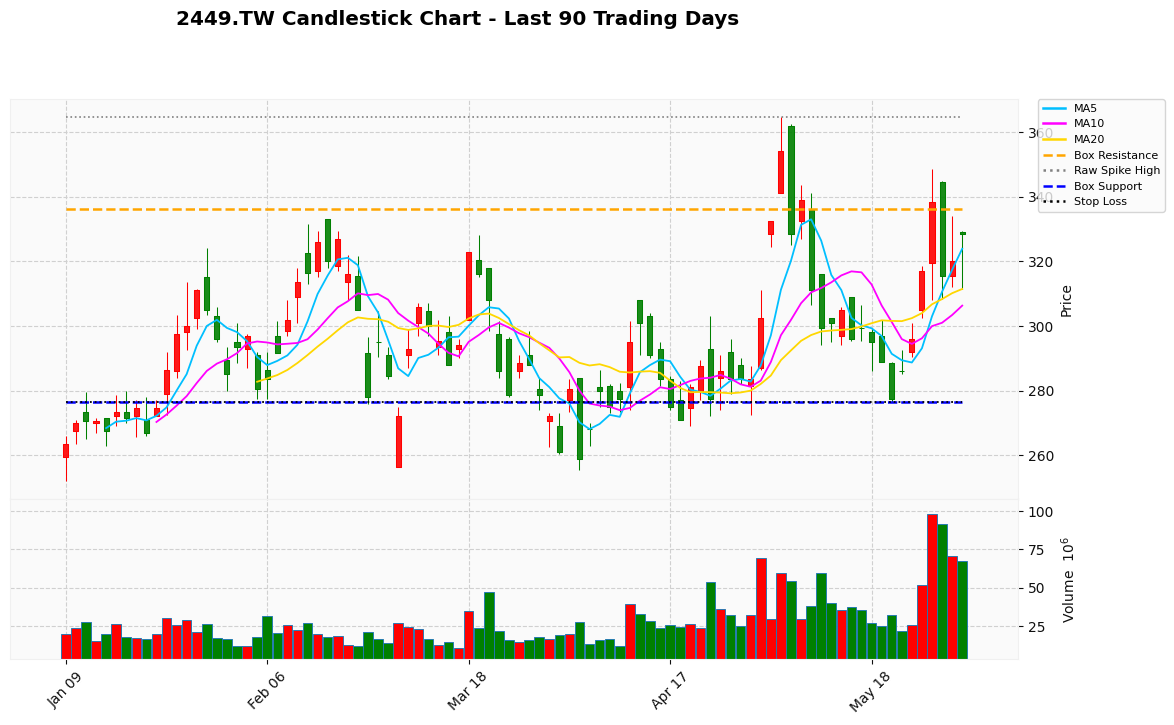

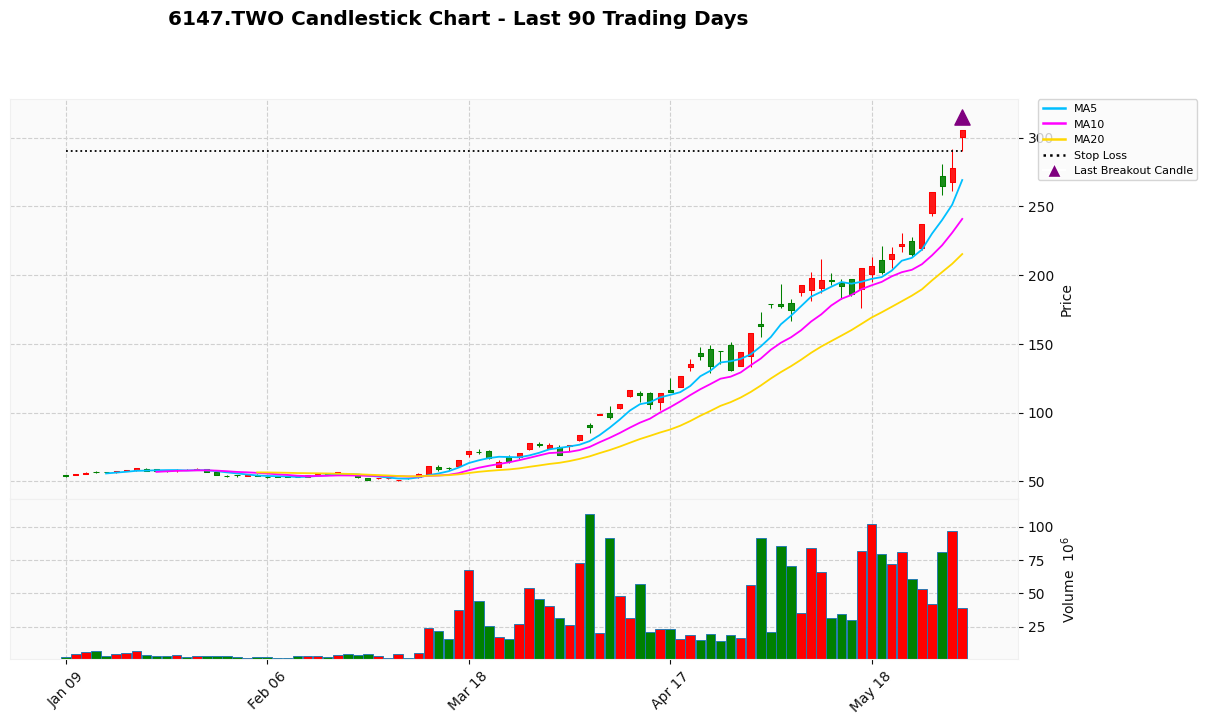

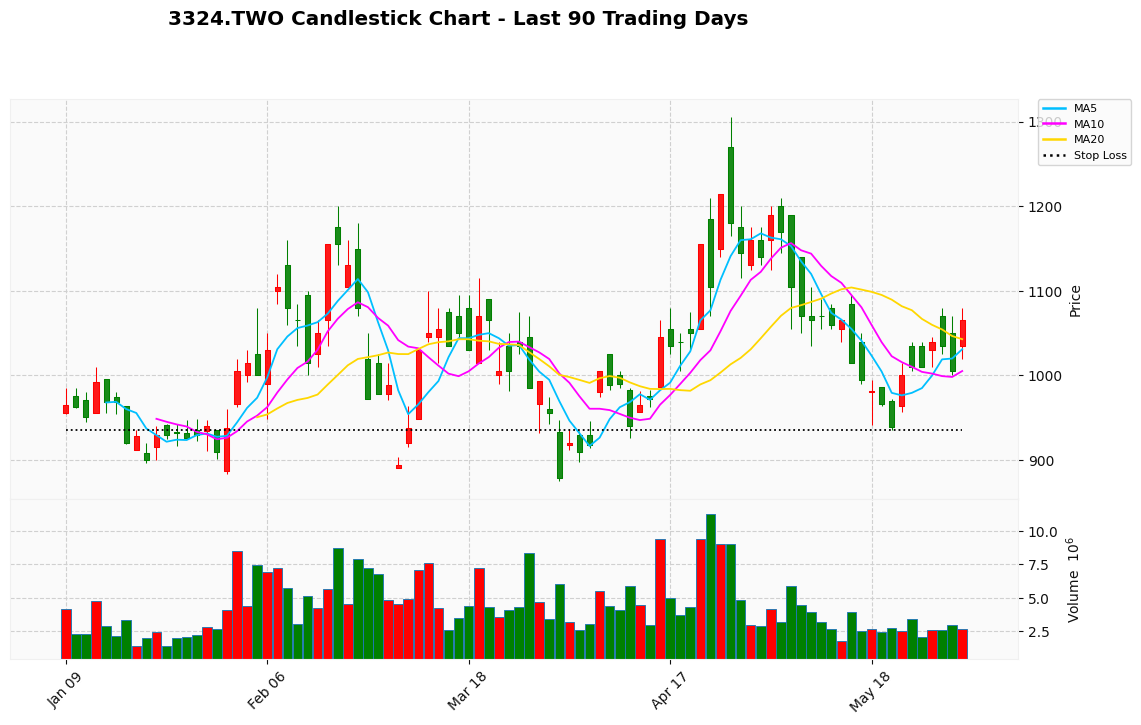

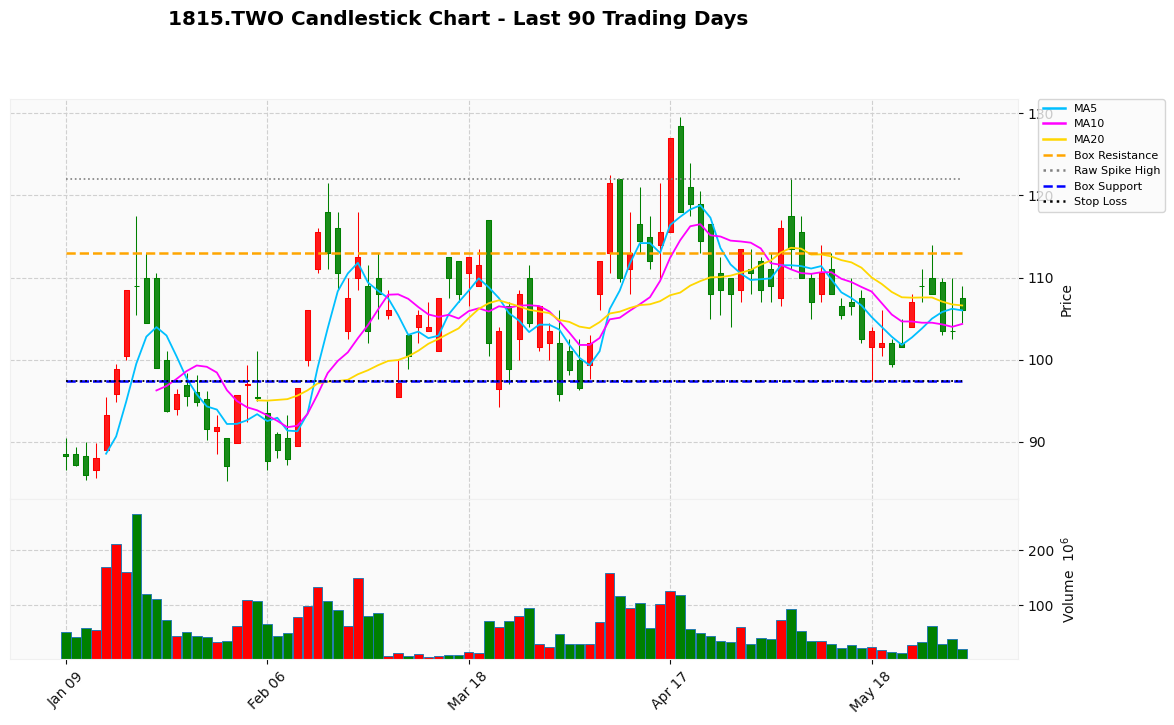

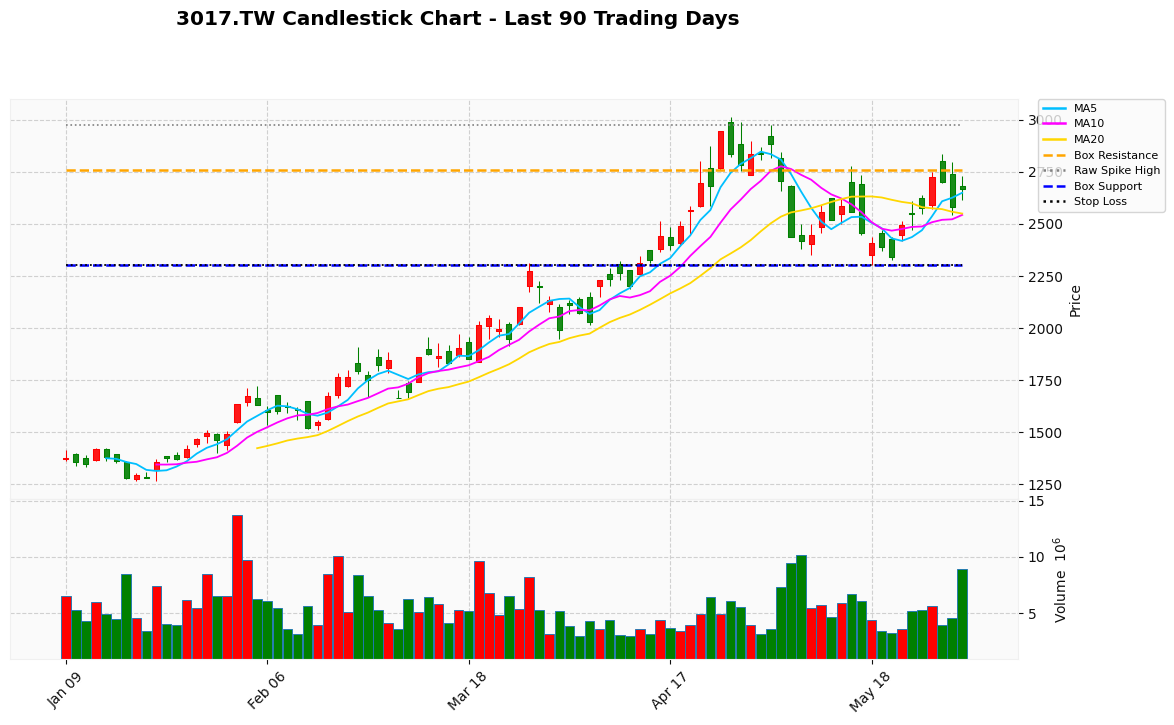

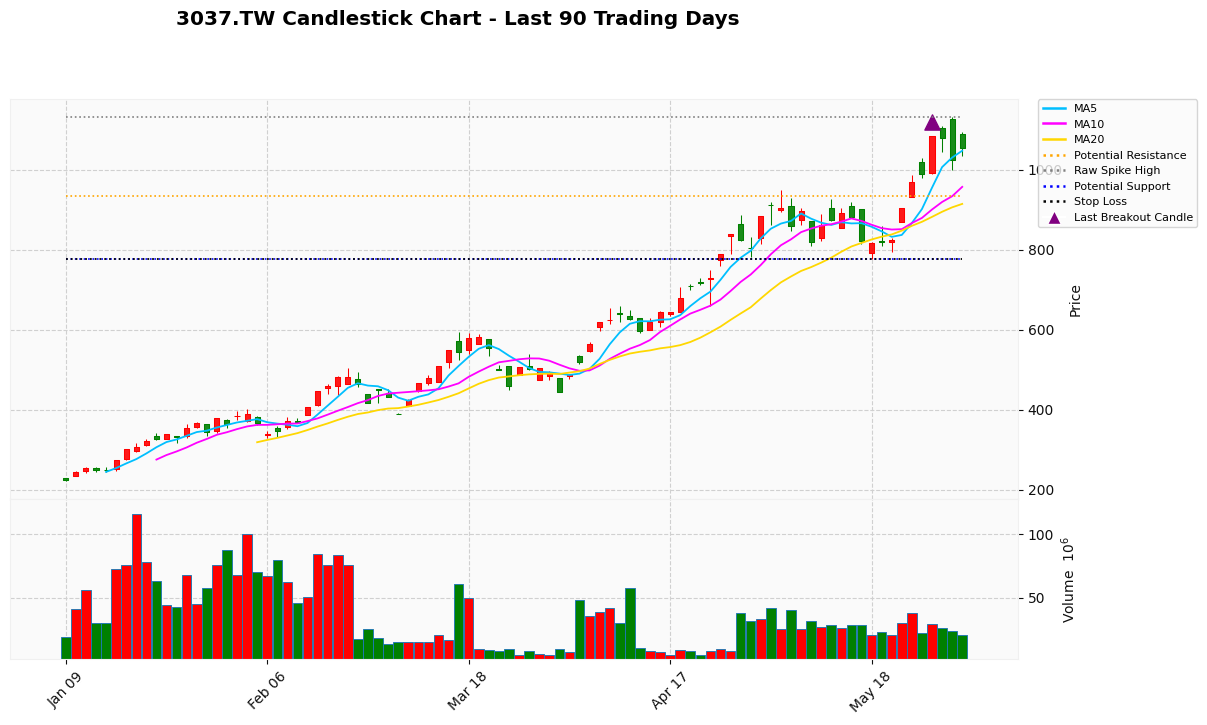

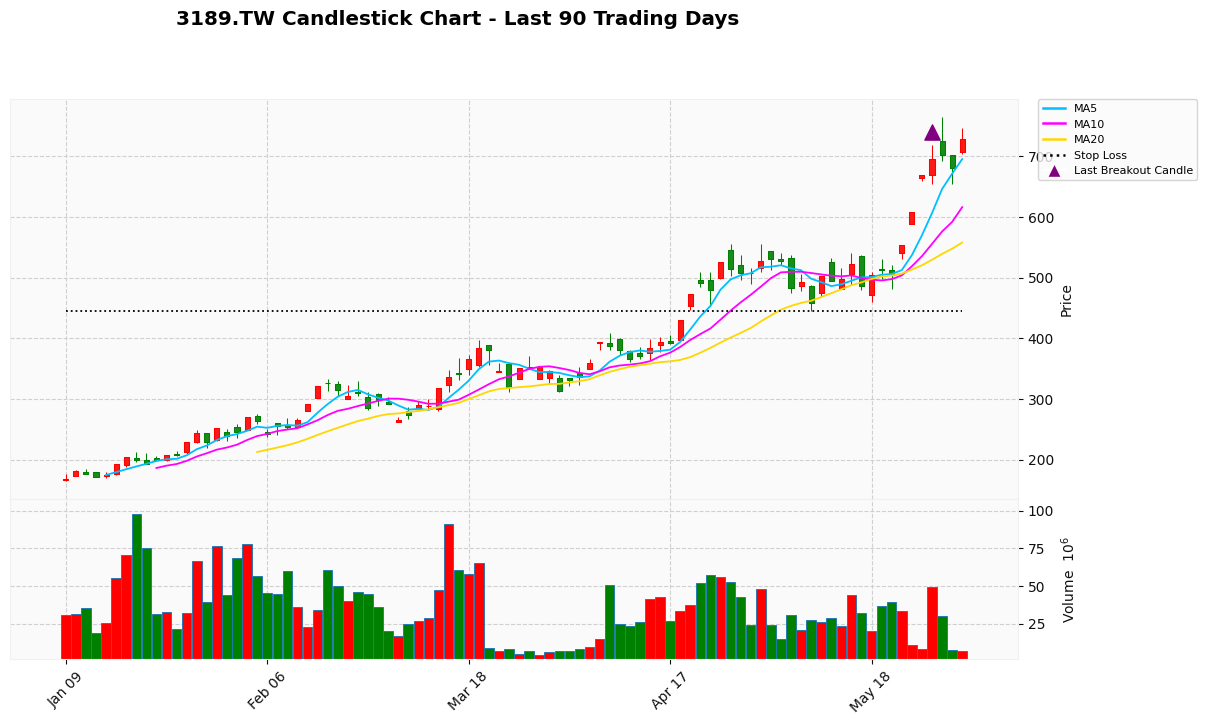

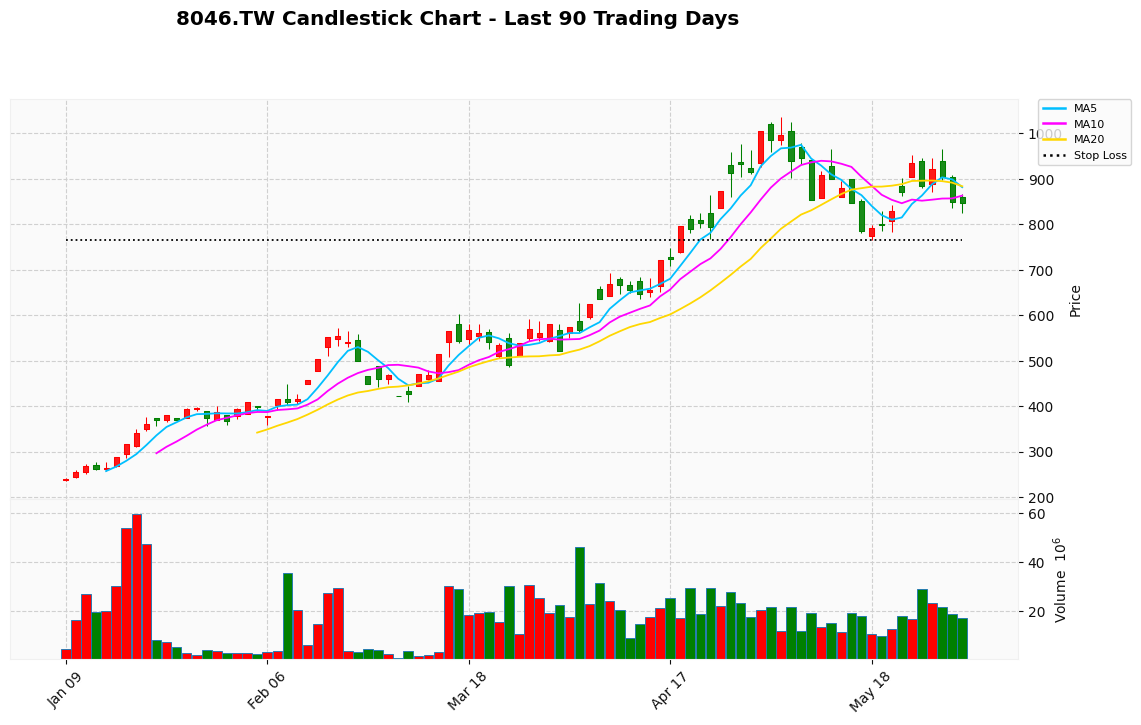

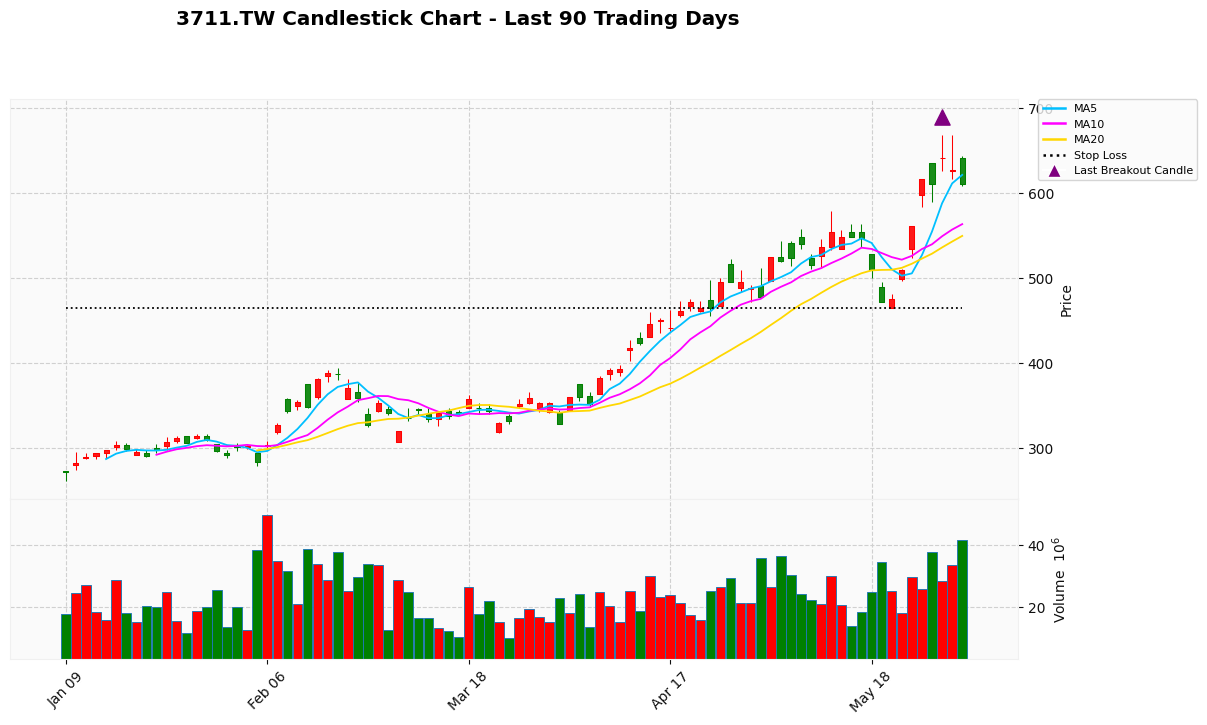

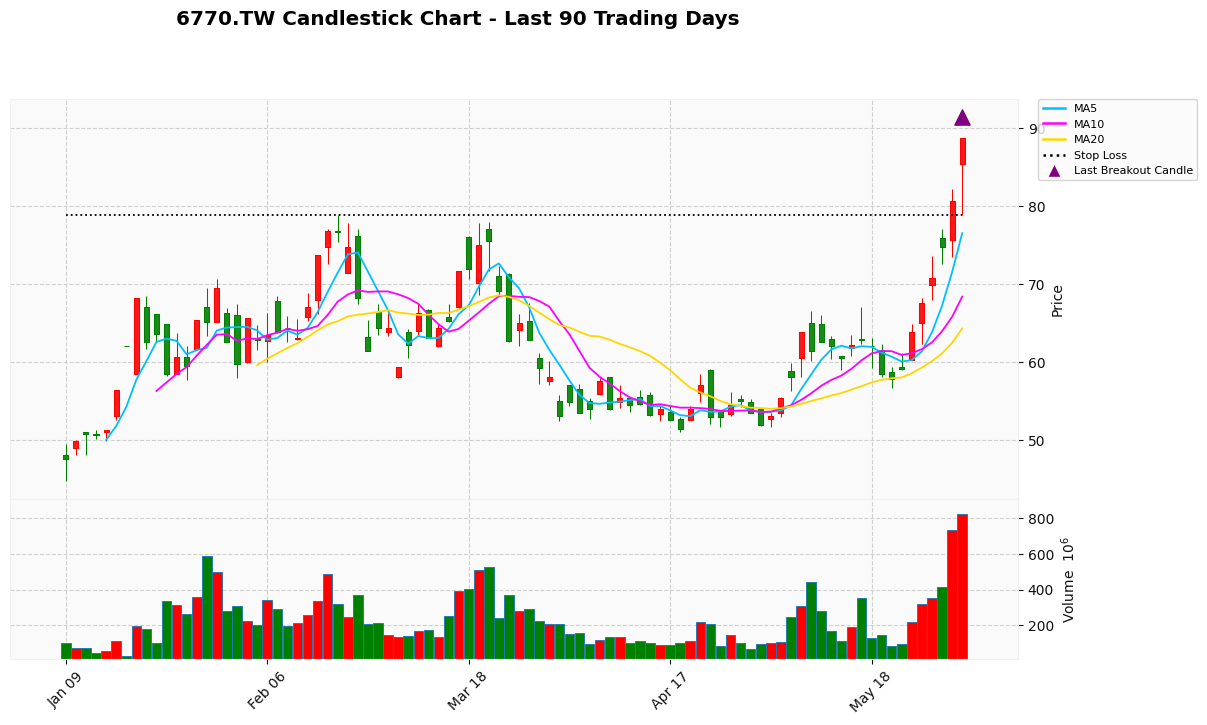

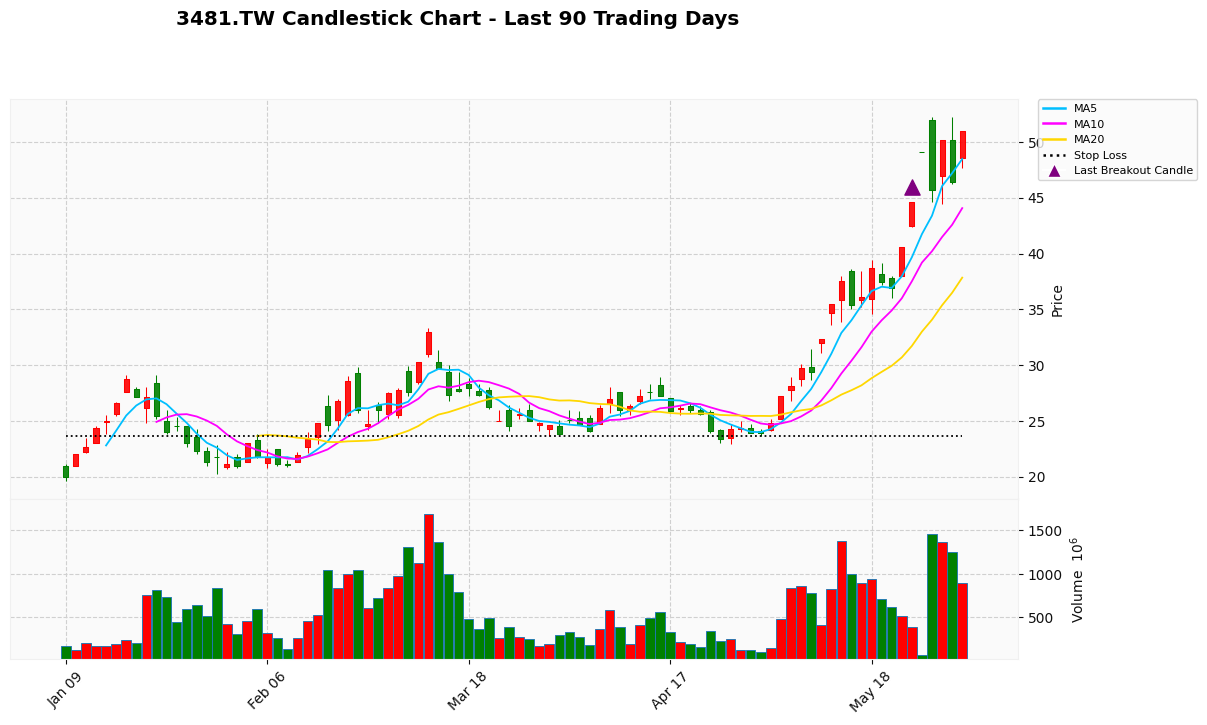

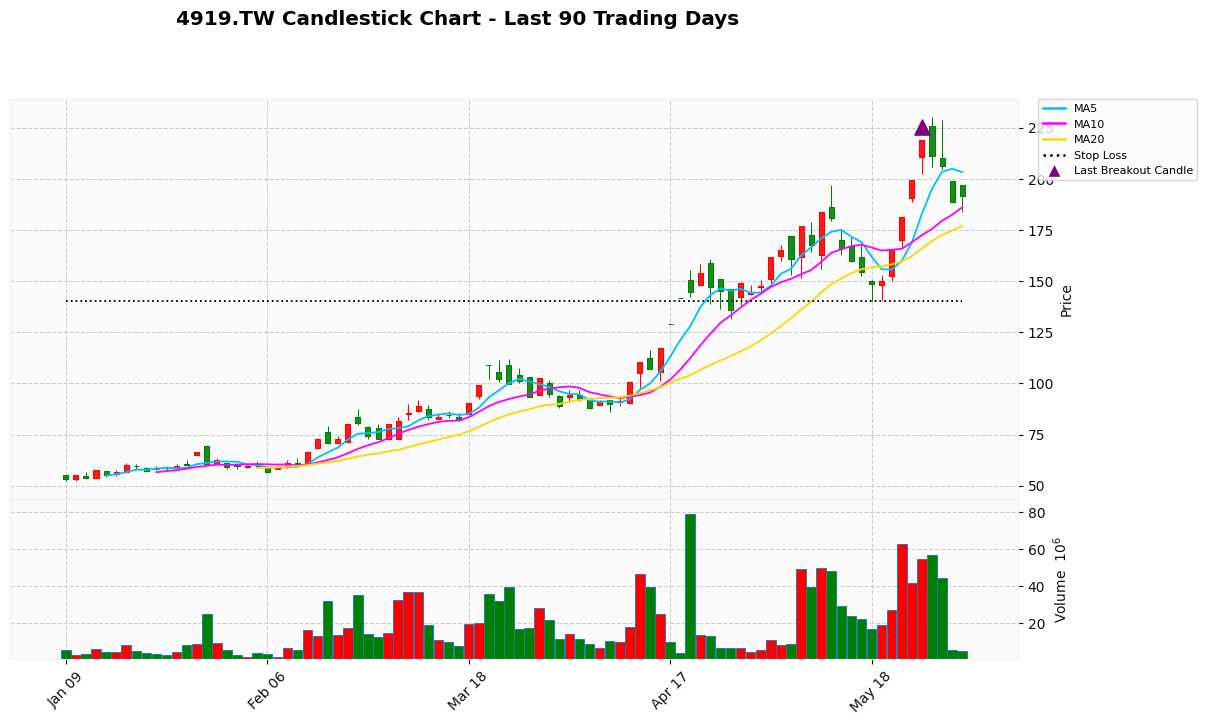

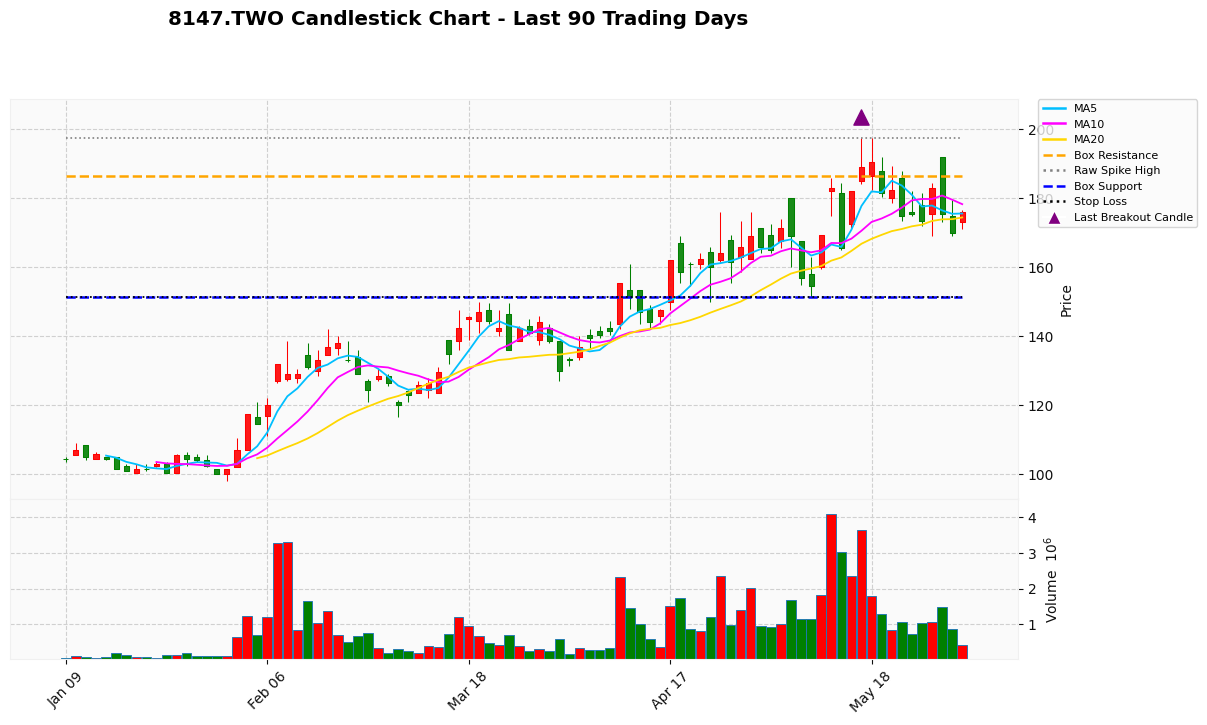

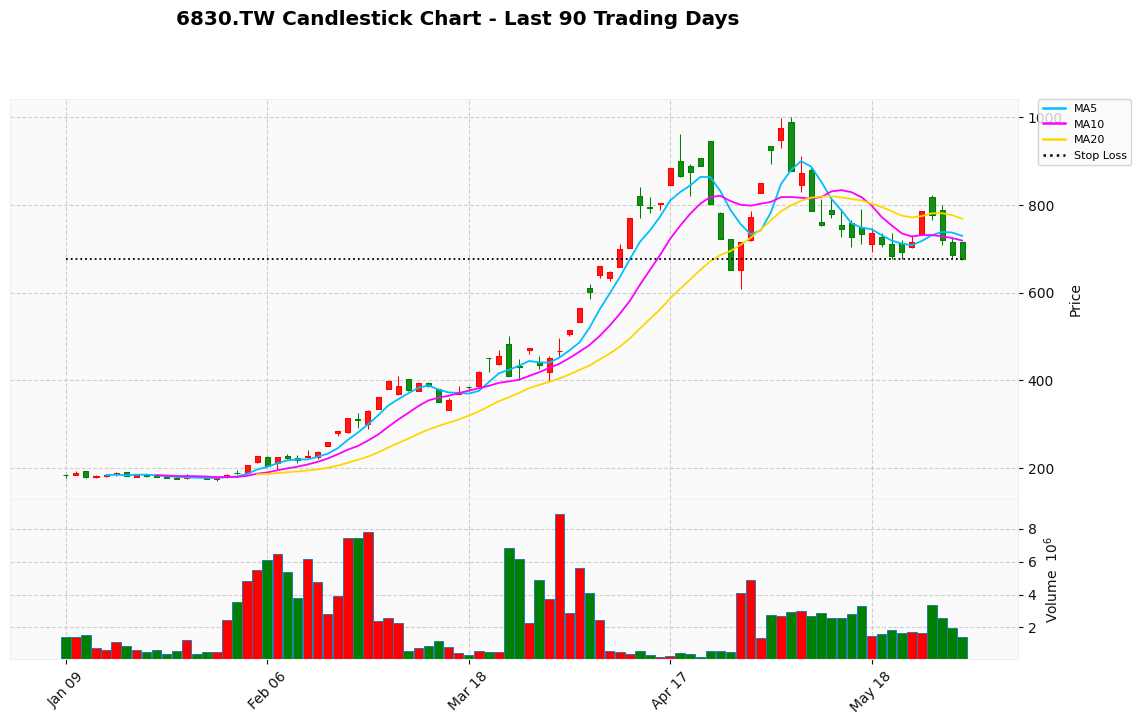

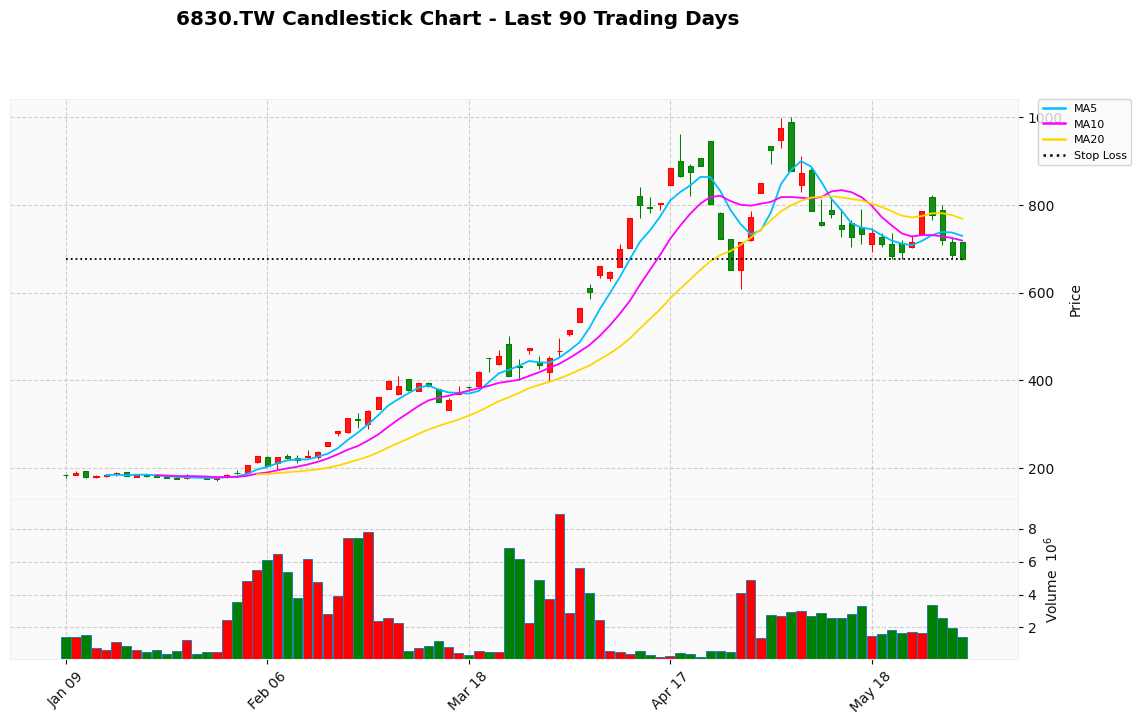

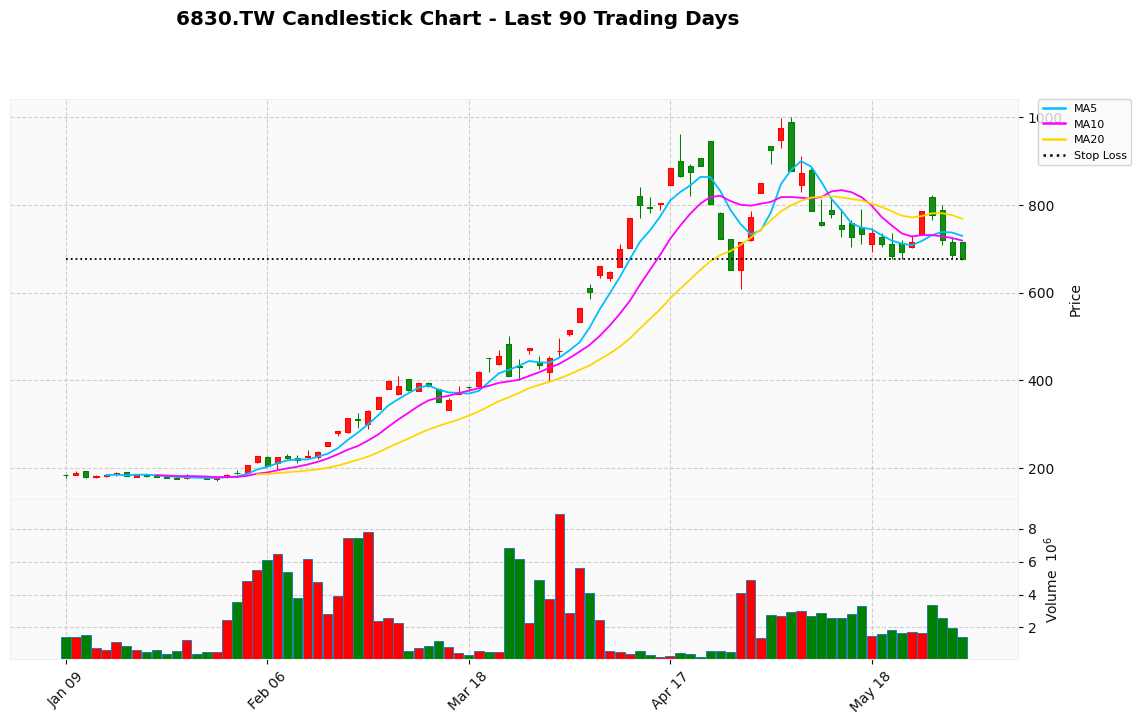

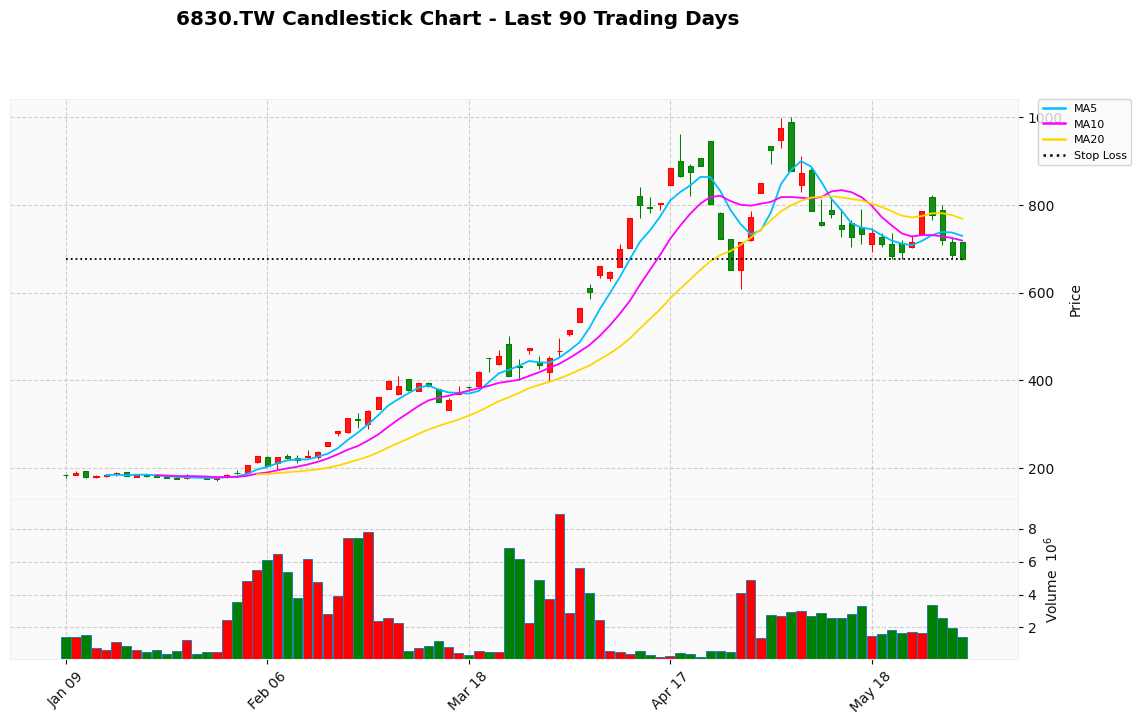

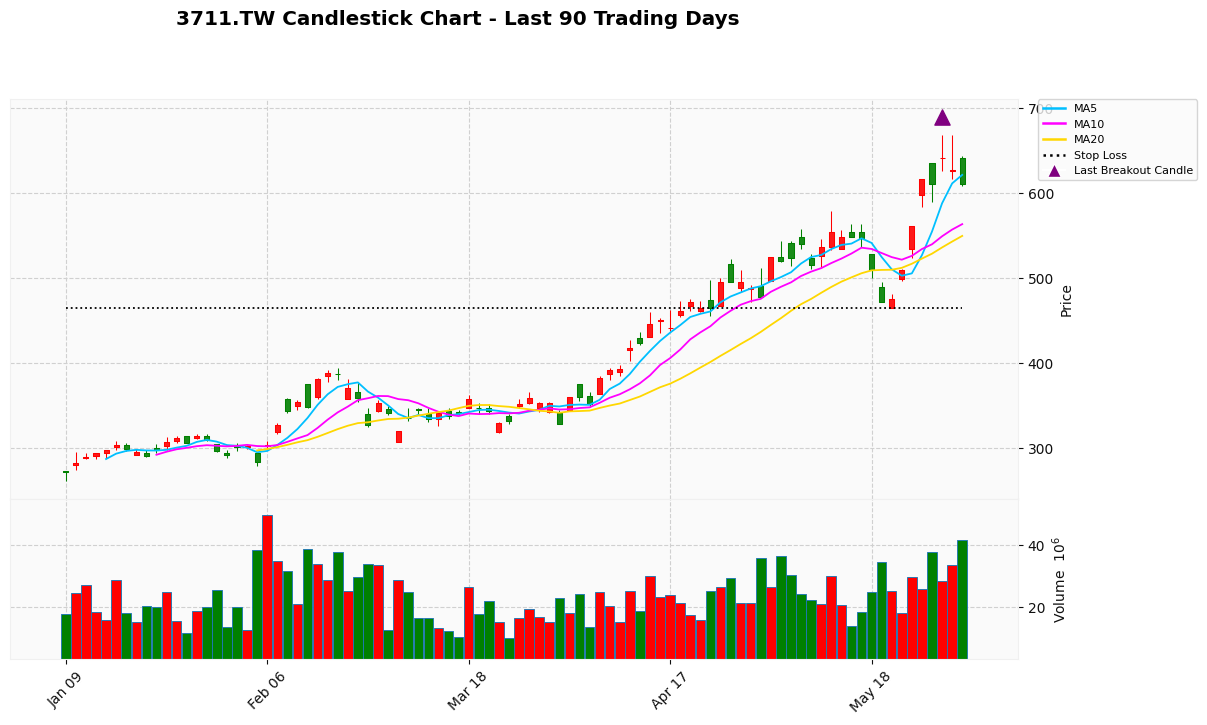

In [212]:
# ============================================================
# 6. Candlestick Figure: Smart Box Lines + MA Legend
# ============================================================
# Taiwan stock color rule:
# - Red: close > open
# - Green: close < open
#
# This version:
# 1. Avoids Chinese labels to prevent font rendering issues
# 2. Uses custom MA colors
# 3. Hides Last Breakout Level and Target Price
# 4. Uses analysis_result["box"]["clear_box"] and ["potential_box"]
# 5. Draws:
#    - confirmed box lines when clear_box == True
#    - potential box lines when potential_box == True
# 6. Moves legend outside the chart

def create_candlestick_figure(df, ticker, analysis_result=None):
    """
    Create candlestick chart for Gradio.

    If analysis_result is provided, this chart may draw:
    - MA5 / MA10 / MA20
    - Box Resistance / Box Support
    - Potential Resistance / Potential Support
    - Raw Spike High
    - Stop Loss
    - Last Breakout Candle marker
    """

    # Use recent 90 candles
    plot_df = df.tail(90).copy()

    # ---------- Taiwan candle colors ----------
    taiwan_market_colors = mpf.make_marketcolors(
        up="red",
        down="green",
        edge="inherit",
        wick="inherit",
        volume="inherit"
    )

    # ---------- Moving Average Colors ----------
    # Avoid red/green because they conflict with candle colors.
    ma_colors = [
        "#00BFFF",  # MA5: Deep Sky Blue
        "#FF00FF",  # MA10: Magenta
        "#FFD700"   # MA20: Gold
    ]

    taiwan_style = mpf.make_mpf_style(
        base_mpf_style="yahoo",
        marketcolors=taiwan_market_colors,
        mavcolors=ma_colors,
        gridstyle="--",
        rc={
            "axes.unicode_minus": False
        }
    )

    addplots = []

    # Legend items format:
    # (label, color, linestyle, kind)
    legend_items = [
        ("MA5", ma_colors[0], "-", "line"),
        ("MA10", ma_colors[1], "-", "line"),
        ("MA20", ma_colors[2], "-", "line")
    ]

    if analysis_result is not None:
        box_data = analysis_result.get("box", {})
        risk_data = analysis_result.get("risk_management", {})
        breakout_analysis = analysis_result.get("breakout_analysis", {})

        box_high = box_data.get("box_high", None)
        box_low = box_data.get("box_low", None)
        raw_box_high = box_data.get("raw_box_high", None)
        box_spike_high = box_data.get("box_spike_high", False)

        clear_box = box_data.get("clear_box", False)
        potential_box = box_data.get("potential_box", False)

        stop_loss = risk_data.get("stop_loss", None)

        breakout_candle = breakout_analysis.get("breakout_candle", {})
        breakout_date = breakout_candle.get("date", None)

        # ============================================================
        # Box display logic
        # ============================================================
        # clear_box=True:
        #   Draw confirmed box lines with thicker dashed lines.
        #
        # clear_box=False and potential_box=True:
        #   Draw potential box lines with thinner dotted lines.
        #
        # clear_box=False and potential_box=False:
        #   Do not draw box lines.
        # ============================================================

        show_confirmed_box = bool(clear_box)
        show_potential_box = bool((not clear_box) and potential_box)
        show_box_lines = bool(show_confirmed_box or show_potential_box)

        # ---------- Confirmed Box Resistance ----------
        if show_confirmed_box and box_high is not None:
            box_high_series = pd.Series(box_high, index=plot_df.index)
            addplots.append(
                mpf.make_addplot(
                    box_high_series,
                    panel=0,
                    color="orange",
                    width=1.8,
                    linestyle="--"
                )
            )
            legend_items.append(("Box Resistance", "orange", "--", "line"))

        # ---------- Potential Box Resistance ----------
        if show_potential_box and box_high is not None:
            box_high_series = pd.Series(box_high, index=plot_df.index)
            addplots.append(
                mpf.make_addplot(
                    box_high_series,
                    panel=0,
                    color="orange",
                    width=1.2,
                    linestyle=":"
                )
            )
            legend_items.append(("Potential Resistance", "orange", ":", "line"))

        # ---------- Raw Spike High ----------
        # If spike high is detected, draw it only when box lines are shown.
        if show_box_lines and box_spike_high and raw_box_high is not None:
            raw_high_series = pd.Series(raw_box_high, index=plot_df.index)
            addplots.append(
                mpf.make_addplot(
                    raw_high_series,
                    panel=0,
                    color="gray",
                    width=1.2,
                    linestyle=":"
                )
            )
            legend_items.append(("Raw Spike High", "gray", ":", "line"))

        # ---------- Confirmed Box Support ----------
        if show_confirmed_box and box_low is not None:
            box_low_series = pd.Series(box_low, index=plot_df.index)
            addplots.append(
                mpf.make_addplot(
                    box_low_series,
                    panel=0,
                    color="blue",
                    width=1.8,
                    linestyle="--"
                )
            )
            legend_items.append(("Box Support", "blue", "--", "line"))

        # ---------- Potential Box Support ----------
        if show_potential_box and box_low is not None:
            box_low_series = pd.Series(box_low, index=plot_df.index)
            addplots.append(
                mpf.make_addplot(
                    box_low_series,
                    panel=0,
                    color="blue",
                    width=1.2,
                    linestyle=":"
                )
            )
            legend_items.append(("Potential Support", "blue", ":", "line"))

        # ============================================================
        # Hidden on purpose:
        # - Last Breakout Level
        # - Target Price
        # ============================================================

        # ---------- Stop Loss ----------
        if stop_loss is not None:
            stop_loss_series = pd.Series(stop_loss, index=plot_df.index)
            addplots.append(
                mpf.make_addplot(
                    stop_loss_series,
                    panel=0,
                    color="black",
                    width=1.3,
                    linestyle=":"
                )
            )
            legend_items.append(("Stop Loss", "black", ":", "line"))

        # ---------- Last Breakout Candle Marker ----------
        # Keep this marker because it helps inspect breakout detection.
        if breakout_date is not None:
            try:
                breakout_timestamp = pd.to_datetime(breakout_date)

                if breakout_timestamp in plot_df.index:
                    marker_series = pd.Series(np.nan, index=plot_df.index)

                    marker_price = plot_df.loc[breakout_timestamp, "High"] * 1.03
                    marker_series.loc[breakout_timestamp] = marker_price

                    addplots.append(
                        mpf.make_addplot(
                            marker_series,
                            panel=0,
                            type="scatter",
                            marker="^",
                            markersize=120,
                            color="purple"
                        )
                    )
                    legend_items.append(("Last Breakout Candle", "purple", None, "marker"))

            except Exception:
                pass

    title = f"{ticker} Candlestick Chart - Last 90 Trading Days"

    plot_kwargs = {
        "type": "candle",
        "volume": True,
        "mav": (5, 10, 20),
        "title": title,
        "style": taiwan_style,
        "figsize": (14, 8),
        "returnfig": True
    }

    if len(addplots) > 0:
        plot_kwargs["addplot"] = addplots

    fig, axes = mpf.plot(plot_df, **plot_kwargs)

    # ---------- Move legend outside ----------
    try:
        from matplotlib.lines import Line2D

        legend_handles = []

        for label, color, linestyle, kind in legend_items:
            if kind == "marker":
                handle = Line2D(
                    [0],
                    [0],
                    marker="^",
                    color="w",
                    markerfacecolor=color,
                    markersize=10,
                    label=label
                )
            else:
                handle = Line2D(
                    [0],
                    [0],
                    color=color,
                    linestyle=linestyle,
                    linewidth=1.8,
                    label=label
                )

            legend_handles.append(handle)

        if len(legend_handles) > 0:
            axes[0].legend(
                handles=legend_handles,
                loc="upper left",
                bbox_to_anchor=(1.02, 1.0),
                borderaxespad=0.0,
                fontsize=8,
                frameon=True
            )

        # Leave room for legend on the right side
        fig.subplots_adjust(right=0.80)

    except Exception:
        pass

    return fig


# ============================================================
# 6-1. Standalone chart test
# ============================================================

def plot_candlestick(df, ticker, analysis_result=None):
    """
    Plot chart directly in Colab.
    """
    fig = create_candlestick_figure(df, ticker, analysis_result)
    return fig


try:
    chart_ticker = analysis_result["stock"]
except Exception:
    try:
        chart_ticker = used_ticker
    except NameError:
        chart_ticker = TICKER

if SHOW_CHART:
    plot_candlestick(df, chart_ticker, analysis_result)

In [213]:
# ============================================================
# 7. 從 Google Drive 讀取 PDF 檔案
# ============================================================
# 這樣就不用每次重新上傳 PDF。
# 只要 PDF 已經放在 Google Drive 裡，
# 每次 Colab 重新啟動後，重新掛載 Drive 即可。

from google.colab import drive
import os

# 掛載 Google Drive
drive.mount("/content/drive")

# 你的 PDF 資料夾路徑
# 如果你的資料夾名稱不同，請改這裡
PDF_FOLDER = "/content/drive/MyDrive/stock_rag_pdfs"

# 兩份 PDF 的完整路徑
pdf_paths = [
    os.path.join(PDF_FOLDER, "新手的技術分析入門講義_小小交易員.pdf"),
    os.path.join(PDF_FOLDER, "第0階段_技術分析入門_小小交易員.pdf")
]

# 檢查檔案是否存在
for path in pdf_paths:
    if not os.path.exists(path):
        raise FileNotFoundError(f"找不到 PDF 檔案：{path}")

print("成功找到 PDF：")
for path in pdf_paths:
    print("-", path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
成功找到 PDF：
- /content/drive/MyDrive/stock_rag_pdfs/新手的技術分析入門講義_小小交易員.pdf
- /content/drive/MyDrive/stock_rag_pdfs/第0階段_技術分析入門_小小交易員.pdf


In [214]:
# ============================================================
# 8. 讀取PDF文字
# ============================================================
# 這裡會把PDF裡面的文字抽出來，之後拿來做RAG檢索。

def read_pdf_text(pdf_path):
    """
    讀取單一PDF文字。
    """
    reader = PdfReader(pdf_path)
    text = ""

    for i, page in enumerate(reader.pages):
        page_text = page.extract_text()

        if page_text:
            text += f"\n\n--- PDF: {pdf_path}, Page {i+1} ---\n"
            text += page_text

    return text


all_pdf_text = ""

for path in pdf_paths:
    all_pdf_text += read_pdf_text(path)

print("PDF文字總長度：", len(all_pdf_text))
print(all_pdf_text[:1000])

PDF文字總長度： 7469


--- PDF: /content/drive/MyDrive/stock_rag_pdfs/新手的技術分析入門講義_小小交易員.pdf, Page 1 ---
 
技術分析從入門到可執行交易流程重點筆記 
 
設計目標：讓新手在筆記內「會看」→「會找」→「會下」→「會管」→「會複盤」。 
筆記內容會以最少的工具，建立可複製的交易 SOP；再次強調指標只作為濾網，避免指標地獄。 
重點：這份筆記可以帶走的三個成果 
 看懂 K線與趨勢，能畫出關鍵支撐／壓力。 
 能用「一套進出場規則」完成一次交易計畫（進場、停損、出場）。 
 理解風控與倉位的底線，能靠複盤自我修正。 
介紹流程 
 K 線強弱＋趨勢定義 
 關鍵價位＋型態：支撐壓力、突破/回踩 
 指標濾網：均線、成交量 
 風控與倉位：停損、停利、(新手就不介紹移動停損停利) 
 組成策略 SOP：市況→選股→觸發→下單 
 複盤與優化：自行記錄、違規診斷 
1｜首先看懂圖表語言：K線＋趨勢 
你只要先掌握三個重要判斷：K 線的強弱、趨勢的方向、以及市場是否在整理。 
K 線是如何形成，可以參照 IG:goodbee_project 其中的文章「什麼是 K 線?」 
這裡就不多贅述。 
K 線強弱： 
 長實體（長紅/長黑）：當期主導力量強，通常代表推進。 
 上影線長：上方賣壓或獲利了結明顯，常見於壓力區。 
 下影線長：下方買盤承接明顯，常見於支撐區。 
上下影線簡單來說就是 K 線留了一條尾巴 ，用下圖作範例: 

--- PDF: /content/drive/MyDrive/stock_rag_pdfs/新手的技術分析入門講義_小小交易員.pdf, Page 2 ---
 
上排（紅色＝陽線）由左到右  只要在盤面上呈現紅色皆稱為紅K 
1. 長實體陽線（K 線實體部分過半都可視為）  
 意義：多方強勢推升，買盤主導。  
 常見解讀：若是在突破/上升趨勢中＝代表這根 K 線偏好續漲，偏多表現。  
2. 紅實體在上＋長下影（長上下影線皆可稱為錘子，因外型像錘子）  
 意義：盤中被殺下去，但被買盤大幅拉回，代表下方支撐強。  
 常見解讀：跌勢末端出現的話可以代表偏「止跌/反轉」的訊號；上升途中出現可能是洗盤
/震盪甚至是回測支撐。

In [215]:
# ============================================================
# 9. 建立 FAISS 向量資料庫
# ============================================================
# 原本我們用 TF-IDF 做關鍵字檢索。
# 現在改成正式一點的 RAG：
#
# PDF文字 chunks
#     ↓
# Gemini Embedding Model 轉成向量
#     ↓
# 存進 FAISS Index
#     ↓
# 使用者問題也轉成向量
#     ↓
# FAISS 找出語意最相近的 PDF 規則段落
#
# 這樣比 TF-IDF 更像真正的 RAG。

def get_gemini_client():
    """
    從 Colab Secrets 讀取 GEMINI_API_KEY，並建立 Gemini client。

    請先在 Colab 左側 Secrets 新增：
    Name  = GEMINI_API_KEY
    Value = 你的 Gemini API Key
    """
    api_key = userdata.get("GEMINI_API_KEY")

    if api_key is None:
        raise ValueError("找不到 GEMINI_API_KEY。請確認你有在 Colab Secrets 新增 API Key。")

    client = genai.Client(api_key=api_key)
    return client


def split_text_into_chunks(text, chunk_size=700, overlap=150):
    """
    把 PDF 文字切成小段。

    chunk_size：每段大約幾個字
    overlap：相鄰段落重疊多少字，避免重要上下文被切斷
    """
    chunks = []

    start = 0
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end]

        if chunk.strip():
            chunks.append(chunk.strip())

        start += chunk_size - overlap

    return chunks


def embed_texts(texts, task_type="RETRIEVAL_DOCUMENT", sleep_seconds=0.1):
    """
    使用 Gemini Embedding Model 把多段文字轉成向量。

    task_type：
    - RETRIEVAL_DOCUMENT：用在 PDF chunks
    - RETRIEVAL_QUERY：用在使用者問題或查詢文字

    回傳：
    numpy array，shape = (文字數量, 向量維度)
    """

    client = get_gemini_client()

    embeddings = []

    for i, text in enumerate(texts):
        response = client.models.embed_content(
            model="gemini-embedding-001",
            contents=text,
            config={
                "task_type": task_type
            }
        )

        # google-genai 的 embed_content 會回傳 embeddings list
        vector = response.embeddings[0].values
        embeddings.append(vector)

        # 避免太密集呼叫 API
        time.sleep(sleep_seconds)

        if (i + 1) % 10 == 0:
            print(f"已完成 embedding：{i + 1}/{len(texts)}")

    embeddings = np.array(embeddings).astype("float32")

    return embeddings


def build_faiss_index(chunks):
    """
    建立 FAISS 向量資料庫。

    我們使用 cosine similarity。
    FAISS 的 IndexFlatIP 是 inner product，
    所以先把向量 normalize 成單位向量後，
    inner product 就等同 cosine similarity。
    """

    print("開始將 PDF chunks 轉成 embeddings...")

    chunk_embeddings = embed_texts(
        chunks,
        task_type="RETRIEVAL_DOCUMENT"
    )

    # 向量正規化，讓 inner product 變成 cosine similarity
    faiss.normalize_L2(chunk_embeddings)

    dimension = chunk_embeddings.shape[1]

    # 建立 FAISS Index
    index = faiss.IndexFlatIP(dimension)
    index.add(chunk_embeddings)

    print("FAISS index 建立完成")
    print("chunks 數量：", len(chunks))
    print("向量維度：", dimension)

    return index, chunk_embeddings


# ============================================================
# 實際建立 chunks 與 FAISS index
# ============================================================
# 注意：
# 這一格會呼叫 Gemini embedding API。
# PDF 沒改的情況下，不需要一直重跑。
# Runtime 重開才需要重新跑。

chunks = split_text_into_chunks(
    all_pdf_text,
    chunk_size=700,
    overlap=150
)

print("切出 PDF chunks 數量：", len(chunks))

faiss_index, chunk_embeddings = build_faiss_index(chunks)

print("第一個 chunk 預覽：")
print(chunks[0][:500])

切出 PDF chunks 數量： 14
開始將 PDF chunks 轉成 embeddings...
已完成 embedding：10/14
FAISS index 建立完成
chunks 數量： 14
向量維度： 3072
第一個 chunk 預覽：
--- PDF: /content/drive/MyDrive/stock_rag_pdfs/新手的技術分析入門講義_小小交易員.pdf, Page 1 ---
 
技術分析從入門到可執行交易流程重點筆記 
 
設計目標：讓新手在筆記內「會看」→「會找」→「會下」→「會管」→「會複盤」。 
筆記內容會以最少的工具，建立可複製的交易 SOP；再次強調指標只作為濾網，避免指標地獄。 
重點：這份筆記可以帶走的三個成果 
 看懂 K線與趨勢，能畫出關鍵支撐／壓力。 
 能用「一套進出場規則」完成一次交易計畫（進場、停損、出場）。 
 理解風控與倉位的底線，能靠複盤自我修正。 
介紹流程 
 K 線強弱＋趨勢定義 
 關鍵價位＋型態：支撐壓力、突破/回踩 
 指標濾網：均線、成交量 
 風控與倉位：停損、停利、(新手就不介紹移動停損停利) 
 組成策略 SOP：市況→選股→觸發→下單 
 複盤與優化：自行記錄、違規診斷 
1｜首先看懂圖表語言：K線＋趨勢 
你只要先掌握三個重要判斷：K 線的強弱、趨勢的方向、以及市場是否在整理。 
K 線是如何形成，可以參照 IG:goodb


In [216]:
# ============================================================
# 10. 用 FAISS 找出跟目前問題最相關的 PDF 規則
# ============================================================
# 這裡取代原本的 TF-IDF retrieve_relevant_rules。
#
# 輸入：
# - user_question：使用者想問 AI 的問題
# - analysis_result：程式算出的股票技術特徵
#
# 輸出：
# - 最相關的 PDF 規則段落

def retrieve_relevant_rules_faiss(query, chunks, index, top_k=6):
    """
    使用 FAISS 根據語意相似度檢索 PDF 規則。
    """

    # 把查詢文字轉成 query embedding
    query_embedding = embed_texts(
        [query],
        task_type="RETRIEVAL_QUERY",
        sleep_seconds=0
    )

    # normalize，才能用 inner product 當 cosine similarity
    faiss.normalize_L2(query_embedding)

    # FAISS 搜尋
    scores, indices = index.search(query_embedding, top_k)

    retrieved = []

    for score, idx in zip(scores[0], indices[0]):
        if idx == -1:
            continue

        retrieved.append({
            "score": float(score),
            "text": chunks[idx],
            "chunk_index": int(idx)
        })

    return retrieved


def build_rag_query(user_question, analysis_result):
    """
    建立 RAG 檢索用的 query。

    這裡不只放使用者問題，
    也把股票技術狀態放進去。
    這樣 FAISS 才能找出跟目前股票狀態有關的 PDF 規則。
    """

    no_trade_text = (
        "；".join(analysis_result["no_trade_reasons"])
        if analysis_result.get("no_trade_reasons")
        else "無"
    )

    market_summary = "無"
    if analysis_result.get("market_context"):
        market_summary = analysis_result["market_context"].get("summary", "無")

    query = f"""
使用者問題：
{user_question}

股票目前技術狀態：
股票代號：{analysis_result["stock"]}
大盤市況：{market_summary}
趨勢：{analysis_result["trend"]["trend_summary"]}
均線：{analysis_result["moving_average"]["status"]}
箱體：{analysis_result["box"]["box_status"]}
突破：{analysis_result["breakout_analysis"]["breakout_status"]}
回踩：{analysis_result["pullback_analysis"]["pullback_status"]}
假突破：{analysis_result["false_breakout_analysis"]["false_breakout_status"]}
成交量倍率：{analysis_result["volume"]["volume_ratio"]}
K線型態：{analysis_result["signal"]["candle_type"]}
停損：{analysis_result["risk_management"]["stop_loss_reason"]}
風險報酬比：{analysis_result["risk_management"]["risk_reward_ratio"]}
禁止交易理由：{no_trade_text}

請檢索 PDF 中與以下主題相關的交易規則：
- 技術分析不是預測，而是建立規則
- 市況判斷
- K線強弱
- 趨勢判斷
- 支撐壓力
- 箱體突破
- 突破後回踩
- 放量突破
- 縮量回踩
- 假突破
- 停損
- 倉位風控
- 交易成本
- 禁止交易清單
"""

    return query


# ============================================================
# 單獨測試用
# ============================================================
# 如果前面已經有 analysis_result，可以測試 FAISS 檢索結果。

default_user_question = "根據 PDF 交易守則，請判斷現在是否符合進場條件。"

try:
    rag_query = build_rag_query(default_user_question, analysis_result)

    retrieved_rules = retrieve_relevant_rules_faiss(
        query=rag_query,
        chunks=chunks,
        index=faiss_index,
        top_k=6
    )

    print("FAISS 檢索到的 PDF 規則：")
    for i, item in enumerate(retrieved_rules, 1):
        print("=" * 80)
        print(f"第 {i} 段 | 相似度分數：{item['score']:.4f} | chunk_index：{item['chunk_index']}")
        print(item["text"][:800])

except NameError:
    print("尚未建立 analysis_result，這段可等第5區塊跑完後再測試。")

FAISS 檢索到的 PDF 規則：
第 1 段 | 相似度分數：0.8080 | chunk_index：7
續段。 
 選股：流動性佳(成交量高至少大於 1000 張)、近期盤整明確、壓力線清楚。 
 觸發：收盤前(大約 13:00左右即可，較不容易遇到假突破)突破壓力即進場（可搭配放量）。 
 停損：跌回箱體內或跌破「突破的那根 K 線」低點（固定擇一）。 
 出場：到前高，或是抓進場到止損價格的價差（假設止損要賠 100，止盈也抓賺 100 出場）。 
以下圖作範例 :當 K 線突破箱體並收盤時即進場做多，止盈位置可以按照自己的風險承受做調整，
也可以抓股票的前高或是壓力位，依個人策略做調整;止損可以設定為當根 K棒低點，或是跌回
箱體內止損。 

--- PDF: /content/drive/MyDrive/stock_rag_pdfs/新手的技術分析入門講義_小小交易員.pdf, Page 7 ---
 
 
SOP B：突破後回踩進場（較穩定） 
 市況：已突破但不追價；等回踩回來再承接。 
 選股：回踩到壓力轉支撐，回踩量縮更佳。 
 觸發：回踩不破支撐，出現止跌即進場（如下影線/收回支撐上方）。 
 停損：支撐下方（結構被破壞）。 
 出場：一樣可以看止損是多少金額，當報酬達標時便立即出場；或碰到下一個壓力出場。 
 
以下圖作範例 :突破不追單，等待價格回測後再進場，止盈一樣可以依個人偏好抓位置，止損可以
抓箱體內的一半或是找出箱體內的支撐點位，跌破出場。 
 
 
 
小提示:若不知道怎麼抓止盈點位，可以先計算這單的止損是幾%，假設止損為 5%，我的止盈就要往
上抓 5%，等於我的風險承受就是 5%的概念。 
 


--- PDF: /cont
第 2 段 | 相似度分數：0.7976 | chunk_index：4
力＋突破/回踩(回踩支撐 or突破壓力都是關鍵) 
所有型態都可以簡化成「關鍵價位附近發生什麼事」。先把支撐/壓力畫對，新手就能少走彎路。 
關鍵價位怎麼找： 
 股價前高/前低：市場記憶最明顯，常形成支撐/壓力。(當下看到的最高以及最低價) 
 密集整理區：盤整區上緣/下緣（箱體）。 下圖中黃色區塊便是盤整區（箱體） 
 趨勢回踩位：上升趨勢回踩前低或均線附近的結構位置。 
突破/回踩： 
 突破：

In [217]:
# ============================================================
# 11. 產生「不用 Gemini」的規則版判斷：補強版
# ============================================================
# 這段可以保證即使沒有 Gemini API Key，專案也能跑。
# Gemini 只是負責把結果解釋得更像人話。
#
# 這裡會根據 PDF 交易守則做 rule-based check：
# 1. 流動性
# 2. 大盤市況
# 3. 均線趨勢
# 4. 箱體是否明確
# 5. 是否放量突破
# 6. 是否突破後回踩
# 7. 假突破風險
# 8. 停損是否可控
# 9. 風險報酬比
# 10. 交易成本
# 11. 禁止交易理由

def rule_based_decision(analysis):
    """
    根據程式算出的特徵，先做一版規則判斷。
    """

    checks = []

    # ---------- 條件1：流動性 ----------
    volume_ok = analysis["volume"]["liquidity_ok"]
    checks.append({
        "rule": "流動性是否足夠",
        "pass": volume_ok,
        "reason": f"今日成交量為 {analysis['price']['volume']} 股；台股1000張約為1,000,000股"
    })

    # ---------- 條件2：大盤市況 ----------
    market_context = analysis.get("market_context", None)

    if market_context is None or not market_context.get("available", False):
        market_ok = True
        market_reason = "未取得大盤資料，因此不列為否決條件"
    else:
        market_summary = market_context.get("summary", "")
        market_ok = "偏弱" not in market_summary
        market_reason = market_summary

    checks.append({
        "rule": "大盤市況是否適合順勢交易",
        "pass": market_ok,
        "reason": market_reason
    })

    # ---------- 條件3：均線趨勢 ----------
    ma_ok = analysis["moving_average"]["ma_bullish"]
    checks.append({
        "rule": "價格是否通過均線趨勢濾網",
        "pass": ma_ok,
        "reason": analysis["moving_average"]["status"]
    })

    # ---------- 條件4：箱體是否明確 ----------
    box_ok = analysis["box"]["clear_box"]
    checks.append({
        "rule": "近期箱體是否明確",
        "pass": box_ok,
        "reason": (
            f"{analysis['box']['box_status']}；"
            f"箱體寬度 {analysis['box']['box_width_pct']}%，"
            f"壓力測試 {analysis['box']['resistance_test_count']} 次，"
            f"支撐測試 {analysis['box']['support_test_count']} 次"
        )
    })

    # ---------- 條件5：是否符合 SOP A 放量突破 ----------
    valid_breakout = analysis["breakout_analysis"]["valid_breakout"]
    breakout_no_long_upper_shadow = not analysis["breakout_analysis"]["breakout_has_long_upper_shadow"]

    sop_a_ok = bool(valid_breakout and box_ok and breakout_no_long_upper_shadow)

    checks.append({
        "rule": "SOP A：是否符合箱體／壓力放量突破",
        "pass": sop_a_ok,
        "reason": analysis["breakout_analysis"]["breakout_status"]
    })

    # ---------- 條件6：是否符合 SOP B 突破後回踩 ----------
    sop_b_ok = analysis["pullback_analysis"]["pullback_candidate"]

    checks.append({
        "rule": "SOP B：是否符合突破後回踩",
        "pass": sop_b_ok,
        "reason": analysis["pullback_analysis"]["pullback_status"]
    })

    # ---------- 條件7：假突破風險 ----------
    false_breakout_risk = (
        analysis["false_breakout_analysis"]["failed_breakout_within_5_days"]
        or analysis["breakout_analysis"]["breakout_has_long_upper_shadow"]
    )

    checks.append({
        "rule": "是否避開假突破風險",
        "pass": not false_breakout_risk,
        "reason": analysis["false_breakout_analysis"]["false_breakout_status"]
    })

    # ---------- 條件8：停損是否可控 ----------
    risk_pct = analysis["risk_management"]["risk_pct"]
    stop_loss_ok = risk_pct is not None and 0 < risk_pct <= 8

    checks.append({
        "rule": "停損幅度是否可控",
        "pass": stop_loss_ok,
        "reason": f"目前估計停損幅度為 {risk_pct}%"
    })

    # ---------- 條件9：風險報酬比 ----------
    rr = analysis["risk_management"]["risk_reward_ratio"]

    if rr is None:
        rr_ok = False
        rr_reason = "無法計算風險報酬比"
    else:
        rr_ok = rr >= 1
        rr_reason = f"估計風險報酬比為 {rr}"

    checks.append({
        "rule": "風險報酬比是否至少達到 1",
        "pass": rr_ok,
        "reason": rr_reason
    })

    # ---------- 條件10：交易成本 ----------
    cost_pct = analysis["transaction_cost"]["estimated_round_trip_cost_pct"]
    cost_ok = cost_pct <= 1

    checks.append({
        "rule": "預估交易成本是否可接受",
        "pass": cost_ok,
        "reason": f"預估來回交易成本約 {cost_pct}%"
    })

    # ---------- 禁止交易理由 ----------
    no_trade_reasons = analysis.get("no_trade_reasons", [])

    has_no_trade_reason = len(no_trade_reasons) > 0

    checks.append({
        "rule": "是否沒有禁止交易理由",
        "pass": not has_no_trade_reason,
        "reason": "；".join(no_trade_reasons) if has_no_trade_reason else "目前沒有明確禁止交易理由"
    })

    # ---------- 總結 ----------
    pass_count = sum(1 for c in checks if c["pass"])
    total_count = len(checks)

    if sop_a_ok and stop_loss_ok and rr_ok and not false_breakout_risk and not has_no_trade_reason:
        decision = "A. 符合 SOP A：箱體／壓力突破進場，可列入觀察進場。"
    elif sop_b_ok and stop_loss_ok and rr_ok and not false_breakout_risk and not has_no_trade_reason:
        decision = "A. 符合 SOP B：突破後回踩進場，可列入觀察進場。"
    elif sop_a_ok or sop_b_ok:
        decision = "B. 部分條件符合，但仍有風險條件未通過，建議等待確認。"
    else:
        decision = "C. 目前不符合明確進場條件，不建議進場。"

    return {
        "checks": checks,
        "pass_count": pass_count,
        "total_count": total_count,
        "no_trade_reasons": no_trade_reasons,
        "decision": decision
    }


rule_decision = rule_based_decision(analysis_result)

print(json.dumps(rule_decision, ensure_ascii=False, indent=2))

{
  "checks": [
    {
      "rule": "流動性是否足夠",
      "pass": true,
      "reason": "今日成交量為 41562162 股；台股1000張約為1,000,000股"
    },
    {
      "rule": "大盤市況是否適合順勢交易",
      "pass": true,
      "reason": "大盤環境偏多，較有利於順勢交易"
    },
    {
      "rule": "價格是否通過均線趨勢濾網",
      "pass": true,
      "reason": "價格在MA20上方，偏多但排列未完全明確"
    },
    {
      "rule": "近期箱體是否明確",
      "pass": false,
      "reason": "近20日斜率明顯向上，較不像箱型整理，偏上升趨勢；箱體寬度 21.29%，壓力測試 10 次，支撐測試 2 次"
    },
    {
      "rule": "SOP A：是否符合箱體／壓力放量突破",
      "pass": false,
      "reason": "尚未突破20日前高"
    },
    {
      "rule": "SOP B：是否符合突破後回踩",
      "pass": false,
      "reason": "最近有突破，但目前尚未回踩到明確支撐位置"
    },
    {
      "rule": "是否避開假突破風險",
      "pass": false,
      "reason": "最近突破後5日內曾跌回突破價下方，疑似假突破風險"
    },
    {
      "rule": "停損幅度是否可控",
      "pass": false,
      "reason": "目前估計停損幅度為 23.9%"
    },
    {
      "rule": "風險報酬比是否至少達到 1",
      "pass": false,
      "reason": "估計風險報酬比為 0.4"
    },
    {
      "rule": "預估交易成本是否可接受",
   

In [218]:
# ============================================================
# 12. 建立給 Gemini 的 Prompt：使用者問題 + FAISS RAG 版
# ============================================================
# 這裡會把：
# 1. 使用者問題
# 2. FAISS 檢索到的 PDF 規則
# 3. 程式計算出的股票技術特徵
# 4. 程式規則版判斷
# 一起交給 Gemini。
#
# Gemini 的任務不是自由預測股價，
# 而是根據 PDF 規則回答使用者問題。

def build_gemini_prompt(user_question, analysis_result, retrieved_rules, rule_decision):
    """
    建立 Gemini 分析用 Prompt。
    """

    rules_text = "\n\n".join([
        f"【PDF規則段落 {i+1} | 相似度 {item['score']:.4f} | chunk {item['chunk_index']}】\n{item['text']}"
        for i, item in enumerate(retrieved_rules)
    ])

    prompt = f"""
你是一位嚴格遵守交易紀律的技術分析助理。

你的任務：
根據「FAISS 檢索到的 PDF 交易規則」與「程式計算出的股票技術特徵」，
回答使用者問題，並判斷目前這檔股票是否符合交易守則。

重要限制：
1. 不可以憑空預測未來股價。
2. 不可以說保證上漲或保證獲利。
3. 不可以把這當成投資建議或喊單。
4. 只能根據提供的股票資料與 PDF 規則判斷。
5. 如果條件不足，要明確說「不符合」或「需要等待」。
6. 如果程式列出 no_trade_reasons，必須優先說明這些禁止交易理由。
7. 你要扮演「交易規則檢查器」，不是「股價預測器」。
8. 若 PDF 規則與股票特徵不足以回答，請直接說資料不足，不要補腦。

====================
一、使用者問題
====================
{user_question}

====================
二、FAISS 檢索到的 PDF 交易規則
====================
{rules_text}

====================
三、程式計算出的股票技術特徵
====================
{json.dumps(analysis_result, ensure_ascii=False, indent=2)}

====================
四、程式規則初步判斷
====================
{json.dumps(rule_decision, ensure_ascii=False, indent=2)}

====================
請輸出以下格式：
====================

# 股票 RAG 技術分析回答

## 1. 對使用者問題的直接回答
請先直接回答使用者問題，不要繞圈。

## 2. 本次引用到的 PDF 規則重點
請整理 FAISS 檢索到的規則，說明這些規則跟本次問題有什麼關係。

## 3. 目前股票狀態摘要
請用 3 到 5 句話說明：
- 股票代號
- 目前趨勢
- 均線狀態
- 成交量狀態
- 大盤市況

## 4. SOP A：箱體／壓力突破進場檢查
請逐條判斷：
- 是否突破壓力
- 是否用收盤價確認
- 是否有放量
- 箱體是否明確
- 突破 K 棒是否有長上影
- 是否可能是假突破
- 停損是否明確

最後給出：符合 / 部分符合 / 不符合

## 5. SOP B：突破後回踩進場檢查
請逐條判斷：
- 最近是否真的有突破
- 是否正在回踩突破支撐
- 是否回踩不破
- 回踩時量能是否健康
- 是否出現止跌訊號
- 停損是否明確

最後給出：符合 / 部分符合 / 不符合

## 6. 風險、倉位與交易成本
請根據提供的停損、單筆風險、建議股數、風險報酬比、交易成本說明：
- 這筆交易如果停損，大約會虧多少
- 建議股數是否合理
- 停損幅度是否過大
- 交易成本是否可能吃掉短線獲利

## 7. 禁止交易理由
如果 no_trade_reasons 不為空，請逐條列出並說明。
如果沒有，請說明目前沒有明確禁止交易理由。

## 8. 最終結論
只能從以下三個選項選一個：

A. 符合規則，可以列入觀察進場
B. 條件不足，等待確認
C. 不符合規則，不建議進場

最後補一句：
這不是投資建議，而是根據交易規則做出的技術面檢查。
"""

    return prompt


# ============================================================
# 單獨測試用
# ============================================================

try:
    gemini_prompt = build_gemini_prompt(
        user_question=default_user_question,
        analysis_result=analysis_result,
        retrieved_rules=retrieved_rules,
        rule_decision=rule_decision
    )

    print(gemini_prompt[:3000])

except NameError:
    print("尚未建立 analysis_result / retrieved_rules / rule_decision，這段可等前面區塊跑完後再測試。")


你是一位嚴格遵守交易紀律的技術分析助理。

你的任務：
根據「FAISS 檢索到的 PDF 交易規則」與「程式計算出的股票技術特徵」，
回答使用者問題，並判斷目前這檔股票是否符合交易守則。

重要限制：
1. 不可以憑空預測未來股價。
2. 不可以說保證上漲或保證獲利。
3. 不可以把這當成投資建議或喊單。
4. 只能根據提供的股票資料與 PDF 規則判斷。
5. 如果條件不足，要明確說「不符合」或「需要等待」。
6. 如果程式列出 no_trade_reasons，必須優先說明這些禁止交易理由。
7. 你要扮演「交易規則檢查器」，不是「股價預測器」。
8. 若 PDF 規則與股票特徵不足以回答，請直接說資料不足，不要補腦。

一、使用者問題
根據 PDF 交易守則，請判斷現在是否符合進場條件。

二、FAISS 檢索到的 PDF 交易規則
【PDF規則段落 1 | 相似度 0.8080 | chunk 7】
續段。 
 選股：流動性佳(成交量高至少大於 1000 張)、近期盤整明確、壓力線清楚。 
 觸發：收盤前(大約 13:00左右即可，較不容易遇到假突破)突破壓力即進場（可搭配放量）。 
 停損：跌回箱體內或跌破「突破的那根 K 線」低點（固定擇一）。 
 出場：到前高，或是抓進場到止損價格的價差（假設止損要賠 100，止盈也抓賺 100 出場）。 
以下圖作範例 :當 K 線突破箱體並收盤時即進場做多，止盈位置可以按照自己的風險承受做調整，
也可以抓股票的前高或是壓力位，依個人策略做調整;止損可以設定為當根 K棒低點，或是跌回
箱體內止損。 

--- PDF: /content/drive/MyDrive/stock_rag_pdfs/新手的技術分析入門講義_小小交易員.pdf, Page 7 ---
 
 
SOP B：突破後回踩進場（較穩定） 
 市況：已突破但不追價；等回踩回來再承接。 
 選股：回踩到壓力轉支撐，回踩量縮更佳。 
 觸發：回踩不破支撐，出現止跌即進場（如下影線/收回支撐上方）。 
 停損：支撐下方（結構被破壞）。 
 出場：一樣可以看止損是多少金額，當報酬達標時便立即出場；或碰到下一個壓力出場。 
 
以下圖作範例 :突破不追單，等待價格回測後再進場，止盈一樣可以依個人偏好抓位置，止損可以
抓箱體內的一半或是找出

In [219]:
# ============================================================
# 13. 呼叫 Gemini API
# ============================================================
# API Key 放在 Colab Secrets：
#
# Name  = GEMINI_API_KEY
# Value = 你的 Gemini API Key

from google import genai
from google.colab import userdata

def call_gemini(prompt):
    """
    呼叫 Gemini 產生分析報告。
    API Key 從 Colab Secret 讀取。
    """

    api_key = userdata.get("GEMINI_API_KEY")

    if api_key is None:
        raise ValueError("找不到 GEMINI_API_KEY。請確認你有在 Colab Secrets 新增 API Key。")

    client = genai.Client(api_key=api_key)

    response = client.models.generate_content(
        model="gemini-3.1-flash-lite",
        config={
            "system_instruction": """
你是一位嚴格遵守交易紀律的技術分析助理。

你只能根據：
1. 程式計算出的股票技術特徵
2. FAISS 檢索到的 PDF 交易規則
3. 使用者問題

來判斷目前是否符合交易規則。

禁止：
- 憑空預測未來股價
- 保證獲利
- 直接喊單
- 給出未根據資料的買賣建議

你的定位是「交易規則檢查器」，不是投資顧問。
"""
        },
        contents=prompt
    )

    return response.text

In [220]:
# ============================================================
# 14. 如果沒有 Gemini，也輸出一份簡單規則版報告
# ============================================================

def print_rule_report(analysis, rule_decision):
    """
    產生不用LLM也能看的規則版報告。
    """
    print("=" * 60)
    print("股票技術分析規則版報告")
    print("=" * 60)

    print(f"股票代號：{analysis['stock']}")
    print(f"日期：{analysis['date']}")
    print(f"收盤價：{analysis['price']['close']}")
    print()

    print("【趨勢】")
    print(analysis["trend"]["trend_summary"])
    print()

    print("【均線】")
    print(analysis["moving_average"]["status"])
    print(f"MA5={analysis['moving_average']['MA5']}, MA10={analysis['moving_average']['MA10']}, MA20={analysis['moving_average']['MA20']}")
    print()

    print("【成交量】")
    print(f"今日成交量：{analysis['volume']['today_volume']}")
    print(f"20日均量：{analysis['volume']['volume_ma20']}")
    print(f"量能倍率：{analysis['volume']['volume_ratio']} 倍")
    print()

    print("【訊號】")
    print(analysis["signal"]["breakout_status"])
    print(analysis["signal"]["pullback_status"])
    print(f"K線型態：{analysis['signal']['candle_type']}")
    print()

    print("【風控】")
    print(f"參考進場價：{analysis['risk_management']['entry_price_reference']}")
    print(f"停損價：{analysis['risk_management']['stop_loss']}")
    print(f"停損理由：{analysis['risk_management']['stop_loss_reason']}")
    print(f"停損幅度：{analysis['risk_management']['risk_pct']}%")
    print(f"單筆最大可承受損失：{analysis['risk_management']['max_loss_money']} 元")
    print(f"建議股數：{analysis['risk_management']['suggested_shares']} 股")
    print(f"約投入金額：{analysis['risk_management']['suggested_position_value']} 元")
    print()

    print("【規則檢查】")
    for check in rule_decision["checks"]:
        mark = "PASS" if check["pass"] else "FAIL"
        print(f"{mark} - {check['rule']}：{check['reason']}")

    print()
    print("【結論】")
    print(rule_decision["decision"])

    print()
    print("提醒：這不是投資建議，只是根據你提供的交易規則做技術面檢查。")


print_rule_report(analysis_result, rule_decision)

股票技術分析規則版報告
股票代號：3711.TW
日期：2026-05-29
收盤價：611.0

【趨勢】
盤整或趨勢不明確

【均線】
價格在MA20上方，偏多但排列未完全明確
MA5=621.6, MA10=563.7, MA20=549.85

【成交量】
今日成交量：41562162
20日均量：27103482
量能倍率：1.53 倍

【訊號】
尚未突破20日前高
最近有突破，但目前尚未回踩到明確支撐位置
K線型態：長黑K，空方力道較強

【風控】
參考進場價：611.0
停損價：465.0
停損理由：未出現明確突破或回踩，暫以20日低點作為結構停損參考
停損幅度：23.9%
單筆最大可承受損失：1000.0 元
建議股數：6 股
約投入金額：3666.0 元

【規則檢查】
PASS - 流動性是否足夠：今日成交量為 41562162 股；台股1000張約為1,000,000股
PASS - 大盤市況是否適合順勢交易：大盤環境偏多，較有利於順勢交易
PASS - 價格是否通過均線趨勢濾網：價格在MA20上方，偏多但排列未完全明確
FAIL - 近期箱體是否明確：近20日斜率明顯向上，較不像箱型整理，偏上升趨勢；箱體寬度 21.29%，壓力測試 10 次，支撐測試 2 次
FAIL - SOP A：是否符合箱體／壓力放量突破：尚未突破20日前高
FAIL - SOP B：是否符合突破後回踩：最近有突破，但目前尚未回踩到明確支撐位置
FAIL - 是否避開假突破風險：最近突破後5日內曾跌回突破價下方，疑似假突破風險
FAIL - 停損幅度是否可控：目前估計停損幅度為 23.9%
FAIL - 風險報酬比是否至少達到 1：估計風險報酬比為 0.4
PASS - 預估交易成本是否可接受：預估來回交易成本約 0.58%
FAIL - 是否沒有禁止交易理由：目前沒有明確突破，也沒有符合突破後回踩；近期突破後曾跌回突破價下方，疑似假突破；停損距離超過8%，風險過大；到下一個目標價的風險報酬比低於1

【結論】
C. 目前不符合明確進場條件，不建議進場。

提醒：這不是投資建議，只是根據你提供的交易規則做技術面檢查。


In [221]:
# ============================================================
# 15. 分離式流程：先分析股票，再詢問 AI
# ============================================================
# 這版把流程拆開：
#
# 1. analyze_stock_only()
#    - 抓股票資料
#    - 計算技術特徵
#    - 分析大盤
#    - 產生 analysis_result
#    - 畫 K 線圖
#    - 不呼叫 FAISS
#    - 不呼叫 Gemini
#
# 2. ask_ai_about_stock()
#    - 使用已經算好的 analysis_result
#    - 根據 user_question 做 FAISS 檢索
#    - 呼叫 Gemini 回答
#
# 好處：
# - 同一檔股票只需要分析一次
# - 可以反覆問 AI 不同問題
# - 測試畫圖時不會消耗 Gemini token

def format_retrieved_rules_for_display(retrieved_rules):
    """
    把 FAISS 檢索到的規則整理成前端可讀的 Markdown。
    """

    if not retrieved_rules:
        return "沒有檢索到相關 PDF 規則。"

    text = "# 本次 FAISS 檢索到的 PDF 規則\n\n"

    for i, item in enumerate(retrieved_rules, 1):
        text += f"## 規則段落 {i}\n\n"
        text += f"- 相似度分數：`{item['score']:.4f}`\n"
        text += f"- chunk index：`{item['chunk_index']}`\n\n"
        text += item["text"][:1200]
        text += "\n\n---\n\n"

    return text


def build_stock_summary_report(analysis_result):
    """
    產生不用 Gemini 的股票技術摘要。
    這份報告只使用程式計算出的資料，不會消耗 token。
    """

    no_trade_reasons = analysis_result.get("no_trade_reasons", [])

    no_trade_text = (
        "\n".join([f"- {reason}" for reason in no_trade_reasons])
        if no_trade_reasons
        else "- 目前沒有明確禁止交易理由"
    )

    breakout_candle = analysis_result.get("breakout_analysis", {}).get("breakout_candle", {})
    box = analysis_result.get("box", {})

    report = f"""
# 股票技術特徵摘要

這份摘要由程式根據 OHLCV 資料自動計算，尚未呼叫 Gemini。

## 股票資訊

- 股票代號：`{analysis_result["stock"]}`
- 日期：`{analysis_result["date"]}`
- 收盤價：`{analysis_result["price"]["close"]}`
- 成交量：`{analysis_result["price"]["volume"]}`

## 大盤市況

- {analysis_result.get("market_context", {}).get("summary", "無大盤資料")}

## 均線狀態

- MA5：`{analysis_result["moving_average"]["MA5"]}`
- MA10：`{analysis_result["moving_average"]["MA10"]}`
- MA20：`{analysis_result["moving_average"]["MA20"]}`
- 判斷：{analysis_result["moving_average"]["status"]}

## 箱體 / 支撐壓力

- 箱體上緣 / 壓力線：`{box.get("box_high")}`
- 箱體下緣 / 支撐線：`{box.get("box_low")}`
- 原始最高點：`{box.get("raw_box_high")}`
- 原始最低點：`{box.get("raw_box_low")}`
- 是否偵測到單一尖刺高點：`{box.get("box_spike_high")}`
- 近20日斜率方向：`{box.get("slope_direction")}`
- 每日斜率百分比：`{box.get("trend_slope_pct_per_day")}%`
- 是否水平整理：`{box.get("slope_is_flat")}`
- 箱體寬度：`{box.get("box_width_pct")}%`
- 壓力測試次數：`{box.get("resistance_test_count")}`
- 支撐測試次數：`{box.get("support_test_count")}`
- 是否明確箱體：`{box.get("clear_box")}`
- 是否潛在箱體：`{box.get("potential_box")}`
- 箱體判斷：{box.get("box_status")}

## 突破 K 棒

- 最近是否有突破 K 棒：`{breakout_candle.get("exists")}`
- 突破日期：`{breakout_candle.get("date")}`
- 突破價位：`{breakout_candle.get("breakout_level")}`
- 突破 K 棒型態：`{breakout_candle.get("candle_type")}`
- 突破 K 棒量能倍率：`{breakout_candle.get("volume_ratio")}`
- 是否長上影：`{breakout_candle.get("has_long_upper_shadow")}`
- 是否為結構較好的突破：`{breakout_candle.get("is_good_structure_breakout")}`

## 停損與倉位

- 參考進場價：`{analysis_result["risk_management"]["entry_price_reference"]}`
- 停損價：`{analysis_result["risk_management"]["stop_loss"]}`
- 停損幅度：`{analysis_result["risk_management"]["risk_pct"]}%`
- 單筆最大可承受損失：`{analysis_result["risk_management"]["max_loss_money"]}`
- 建議股數：`{analysis_result["risk_management"]["suggested_shares"]}`
- 約投入金額：`{analysis_result["risk_management"]["suggested_position_value"]}`
- 風險報酬比：`{analysis_result["risk_management"]["risk_reward_ratio"]}`

## 禁止交易理由

{no_trade_text}
"""

    return report


def analyze_stock_only(
    ticker,
    period,
    capital,
    risk_per_trade
):
    """
    只分析股票與畫 K 線圖，不呼叫 FAISS / Gemini。
    回傳：
    1. 技術摘要
    2. K 線圖
    3. analysis_result 狀態
    """

    try:
        # ---------- 1. 抓個股資料 ----------
        df, used_ticker = fetch_stock_data(
            ticker=ticker,
            period=period,
            interval="1d"
        )

        # ---------- 2. 計算技術分析特徵 ----------
        df = ensure_technical_columns(df)

        # ---------- 3. 分析大盤市況 ----------
        market_context = analyze_market_context(period=period)

        # ---------- 4. 整理最新訊號 ----------
        analysis_result = analyze_latest_signal(
            df=df,
            ticker=used_ticker,
            capital=float(capital),
            risk_per_trade=float(risk_per_trade),
            market_context=market_context
        )

        # ---------- 5. 產生 K 線圖 ----------
        fig = create_candlestick_figure(
            df=df,
            ticker=used_ticker,
            analysis_result=analysis_result
        )

        # ---------- 6. 產生技術摘要 ----------
        summary_report = build_stock_summary_report(analysis_result)

        return summary_report, fig, analysis_result

    except Exception as e:
        return f"發生錯誤：{str(e)}", None, None


def ask_ai_about_stock(
    user_question,
    analysis_result
):
    """
    使用已經分析好的 analysis_result 問 AI。
    這裡才會呼叫：
    - FAISS retrieval
    - Gemini embedding
    - Gemini text generation
    """

    try:
        if analysis_result is None:
            return (
                "請先按「分析股票並畫 K 線圖」，產生股票分析結果後再詢問 AI。",
                "尚未有股票分析結果，因此沒有檢索 PDF 規則。"
            )

        if user_question is None or str(user_question).strip() == "":
            user_question = "根據 PDF 交易守則，請判斷現在是否符合進場條件。"

        # ---------- 1. 建立 FAISS RAG 查詢 ----------
        rag_query = build_rag_query(
            user_question=user_question,
            analysis_result=analysis_result
        )

        # ---------- 2. 用 FAISS 從 PDF 規則中檢索相關內容 ----------
        retrieved_rules = retrieve_relevant_rules_faiss(
            query=rag_query,
            chunks=chunks,
            index=faiss_index,
            top_k=6
        )

        # ---------- 3. 先做規則版判斷 ----------
        rule_decision = rule_based_decision(analysis_result)

        # ---------- 4. 建立 Gemini Prompt ----------
        gemini_prompt = build_gemini_prompt(
            user_question=user_question,
            analysis_result=analysis_result,
            retrieved_rules=retrieved_rules,
            rule_decision=rule_decision
        )

        # ---------- 5. 呼叫 Gemini ----------
        gemini_report = call_gemini(gemini_prompt)

        # ---------- 6. 整理檢索結果 ----------
        retrieved_rules_markdown = format_retrieved_rules_for_display(retrieved_rules)

        return gemini_report, retrieved_rules_markdown

    except Exception as e:
        return f"發生錯誤：{str(e)}", "因為發生錯誤，所以沒有檢索結果。"

In [222]:
# ============================================================
# 16. Gradio 前端：先分析股票，再詢問 AI
# ============================================================
# 這版有兩個主要按鈕：
#
# 1. 分析股票並畫 K 線圖
#    - 不呼叫 AI
#    - 不消耗 Gemini token
#    - 會把 analysis_result 存在 gr.State
#
# 2. 詢問 AI
#    - 使用已經存在的 analysis_result
#    - 做 FAISS 檢索
#    - 呼叫 Gemini 回答問題

with gr.Blocks(title="股票 RAG 進場時機分析助手") as demo:

    # 用來儲存目前這檔股票的分析結果
    analysis_state = gr.State(value=None)

    gr.Markdown("""
# 股票 RAG 進場時機分析助手

流程分成兩步：

1. **先分析股票並畫 K 線圖**
   系統會抓 yfinance 資料、計算技術特徵、畫出 K 線圖。這一步不會呼叫 Gemini，不會消耗 token。

2. **再詢問 AI**
   系統會根據目前這檔股票的技術特徵，使用 FAISS 從 PDF 交易守則中檢索相關規則，再交給 Gemini 回答。

注意：這不是投資建議，而是交易規則檢查工具。
""")

    gr.Markdown("## Step 1：分析股票")

    with gr.Row():
        ticker_input = gr.Textbox(
            label="股票代號",
            value="2449",
            placeholder="例如：2330、3711、6488、2449、6147、2330.TW、6488.TWO"
        )

        period_input = gr.Dropdown(
            label="資料期間",
            choices=["3mo", "6mo", "1y"],
            value="6mo"
        )

    with gr.Row():
        capital_input = gr.Number(
            label="總資金",
            value=100000
        )

        risk_input = gr.Number(
            label="單筆最大虧損比例",
            value=0.01
        )

    analyze_button = gr.Button("分析股票並畫 K 線圖（不使用 AI）")

    with gr.Row():
        output_chart = gr.Plot(
            label="K 線圖"
        )

    stock_summary_output = gr.Markdown(
        label="程式技術分析摘要"
    )

    gr.Markdown("---")
    gr.Markdown("## Step 2：詢問 AI")

    user_question_input = gr.Textbox(
        label="想問 AI 的問題",
        value="根據 PDF 交易守則，請判斷現在是否符合進場條件。",
        placeholder="例如：這檔股票比較像突破進場，還是突破後回踩？有沒有假突破風險？停損和倉位合理嗎？",
        lines=3
    )

    ask_ai_button = gr.Button("詢問 AI（會使用 FAISS + Gemini，會消耗 token）")

    ai_report_output = gr.Markdown(
        label="Gemini RAG 回答"
    )

    with gr.Accordion("查看本次 FAISS 檢索到的 PDF 規則", open=False):
        retrieved_rules_output = gr.Markdown(
            label="FAISS 檢索結果"
        )

    # Step 1：只分析股票，不呼叫 AI
    analyze_button.click(
        fn=analyze_stock_only,
        inputs=[
            ticker_input,
            period_input,
            capital_input,
            risk_input
        ],
        outputs=[
            stock_summary_output,
            output_chart,
            analysis_state
        ]
    )

    # Step 2：使用已經分析好的 analysis_result 問 AI
    ask_ai_button.click(
        fn=ask_ai_about_stock,
        inputs=[
            user_question_input,
            analysis_state
        ],
        outputs=[
            ai_report_output,
            retrieved_rules_output
        ]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7d143ebcd231d3be87.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
